Libraries imported successfully.
 Model loaded successfully from:
  ./Results/Trained_Models/RS42_consensus_n7_fast_aggr_False_DecisionTree_model.pkl

 Training data loaded successfully from:
  ./Results/Selected_Data/RS42_consensus_n7_fast_aggr_False_train_data.parquet (shape: (53, 8))
 Test data loaded successfully from:
  ./Results/Selected_Data/RS42_consensus_n7_fast_aggr_False_test_data.parquet (shape: (10, 8))
 Predictions made for both training and test sets.
  - Training predictions shape: (53,)
  - Test predictions shape: (10,)
╔═════════════════╦═════════════╦═════════════╗
║   Metric        ║  Train Set  ║   Test Set  ║
╠═════════════════╬═════════════╬═════════════╣
║ R² (R-squared)  ║   0.7116    ║   0.6522    ║
║ RMSE            ║   16.86      ║   18.35      ║
╚═════════════════╩═════════════╩═════════════╝


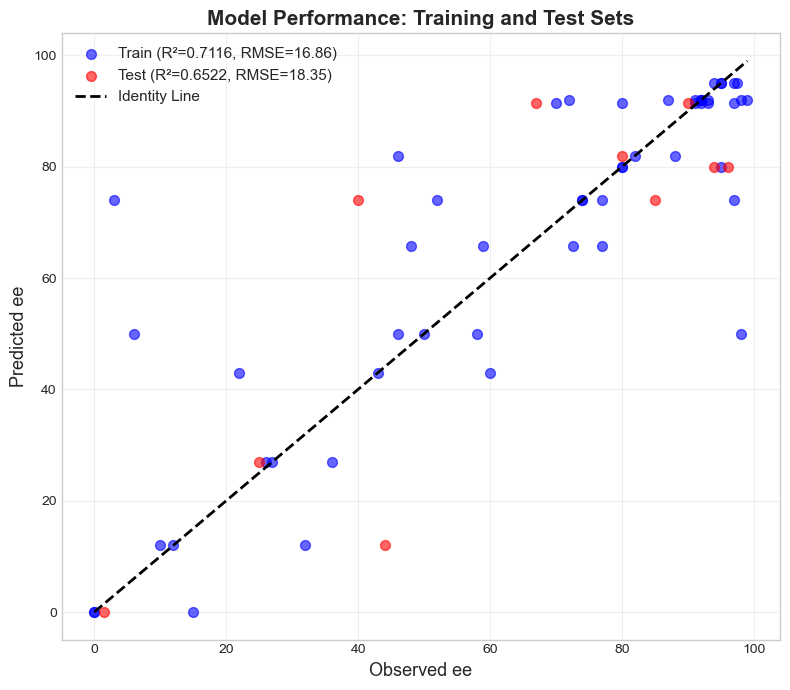

 Combined plot generated successfully


In [1]:
# # QSPR Model Verification and Visualization
# 
# This notebook loads a previously trained model and its corresponding training/test data to:
# 1.  Verify the model's performance by recalculating key metrics.
# 2.  Generate a publication-quality scatter plot of observed vs. predicted values.
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

print("Libraries imported successfully.")

# ===================================================================
# CONFIGURATION: Specify file paths
# ===================================================================
model_path = './Results/Trained_Models/RS42_consensus_n7_fast_aggr_False_DecisionTree_model.pkl'
train_data_path = './Results/Selected_Data/RS42_consensus_n7_fast_aggr_False_train_data.parquet'
test_data_path = './Results/Selected_Data/RS42_consensus_n7_fast_aggr_False_test_data.parquet'

# Load the model
model = joblib.load(model_path)
print(f" Model loaded successfully from:\n  {model_path}\n")

# Load the datasets
train_df = pd.read_parquet(train_data_path)
test_df = pd.read_parquet(test_data_path)
print(f" Training data loaded successfully from:\n  {train_data_path} (shape: {train_df.shape})")
print(f" Test data loaded successfully from:\n  {test_data_path} (shape: {test_df.shape})")
# ## Prepare Data and Make Predictions

# ===================================================================
# DATA PREPARATION AND PREDICTION
# ===================================================================
# Separate features (X) and target (y)
TARGET_COLUMN = 'ee'

X_train = train_df.drop(columns=[TARGET_COLUMN])
X_train = X_train[list(train_df.iloc[:, :-1].columns)]
y_train = train_df[TARGET_COLUMN]

X_test = test_df.drop(columns=[TARGET_COLUMN])
X_test = X_test[list(train_df.iloc[:, :-1].columns)]
y_test = test_df[TARGET_COLUMN]

# Make predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print(" Predictions made for both training and test sets.")
print(f"  - Training predictions shape: {y_pred_train.shape}")
print(f"  - Test predictions shape: {y_pred_test.shape}")

# ===================================================================
# PERFORMANCE VERIFICATION
# ===================================================================
# Calculate metrics for the training set
train_r2 = r2_score(y_train, y_pred_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))

# Calculate metrics for the test set
test_r2 = r2_score(y_test, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("╔═════════════════╦═════════════╦═════════════╗")
print("║   Metric        ║  Train Set  ║   Test Set  ║")
print("╠═════════════════╬═════════════╬═════════════╣")
print(f"║ R² (R-squared)  ║   {train_r2:.4f}    ║   {test_r2:.4f}    ║")
print(f"║ RMSE            ║   {train_rmse:.2f}      ║   {test_rmse:.2f}      ║")
print("╚═════════════════╩═════════════╩═════════════╝")

# ===================================================================
# PLOT OBSERVED VS. PREDICTED (COMBINED) AND SAVE FIGURE
# ===================================================================
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(1, 1, figsize=(8, 7))

# Plot both training and test data on the same axes
ax.scatter(y_train, y_pred_train, c='blue', alpha=0.6, s=50, label=f'Train (R²={train_r2:.4f}, RMSE={train_rmse:.2f})')
ax.scatter(y_test, y_pred_test, c='red', alpha=0.6, s=50, label=f'Test (R²={test_r2:.4f}, RMSE={test_rmse:.2f})')

# Identity line
all_y = np.concatenate([y_train, y_test])
all_pred = np.concatenate([y_pred_train, y_pred_test])
min_val = min(all_y.min(), all_pred.min())
max_val = max(all_y.max(), all_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Identity Line')

# Labels and title
ax.set_xlabel('Observed ee', fontsize=13)
ax.set_ylabel('Predicted ee', fontsize=13)
ax.set_title('Model Performance: Training and Test Sets', fontsize=15, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig('model_performance_combined.svg', format='svg', dpi=300, bbox_inches='tight')

plt.show()

print(" Combined plot generated successfully")

In [2]:
model[2]

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'absolute_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

In [3]:
## Validation set

import sys
import pandas as pd
import numpy as np
import pickle
import warnings
from pathlib import Path
from datetime import datetime

# Add module path for imports
module_path = Path('.').parent / 'module'  # Adjust if needed
if module_path.exists():
    sys.path.insert(0, str(module_path))
    print(f" Module path added: {module_path}")
else:
    print(f" Module path not found: {module_path}")
    print(f"  Current directory: {Path('.').resolve()}")
    print(f"  Please ensure calculate_descriptors.py is in a 'module' subdirectory")

warnings.filterwarnings('ignore')

# Import from your QSPR module
try:
    from calculate_descriptors import prepare_data
    print(" Successfully imported from calculate_descriptors.py")
except ImportError as e:
    print(f" Error importing from models_creation.py: {e}")
    raise

print("\n All imports successful")

 Module path added: module

╔════════════════════════════════════════════════════════════════════════════╗
║                                                                            ║
║                calculate_descriptors.py MODULE READY                       ║
║                                                                            ║
║         Import this module in your QSPR analysis scripts                   ║
║         Location: module/calculate_descriptors.py                          ║
║                                                                            ║
╚════════════════════════════════════════════════════════════════════════════╝
    
 Successfully imported from calculate_descriptors.py

 All imports successful


In [4]:
CONFIG = {
    # Data file
    'data': './Data/Exp_verification_III_modyfikacja_10struktur.xlsx',
    'target_col': 'ee',
    'name': 'validation_set',
    'mode': 'validation',
    'output_dir': './Data/'
}

In [5]:
# ============================================================================
# SECTION 3: LOAD DATA & CALCULATE ALL DESCRIPTORS
# ============================================================================

print('\n' + "█"*75)
print("█" + " STEP 1: LOAD DATA & CALCULATE ALL DESCRIPTORS ".center(73) + "█")
print("█"*75)

print(f"\nLoading data from: {CONFIG['data']}")
print(f"Calculating all descriptors: Mordred, Morgan, CircuS, ChemBERTa, Sterimol, Electronic")
print(f"This may take 5-15 minutes depending on dataset size...")

try:
    # Calculate ALL descriptors (full set)
    data = prepare_data(
        CONFIG['data'],
        CONFIG['target_col'],
        CONFIG['name'],
        CONFIG['mode'],
        CONFIG['output_dir'],
       
    )
    
    print(f"\n Data loaded and ALL descriptors calculated")
    print(f"  Total samples: {data.shape[0]}")
    print(f"  Total features: {data.shape[1]-1} (+ target)")
    print(f"  Target range: [{data[CONFIG['target_col']].min():.1f}, {data[CONFIG['target_col']].max():.1f}]")
    print(f"  Target mean: {data[CONFIG['target_col']].mean():.2f}")
    print(f"  Target std: {data[CONFIG['target_col']].std():.2f}")
    
except Exception as e:
    print(f"\n Error loading data: {e}")
    print(f"\n  Try these solutions:")
    print(f"  1. Check if {CONFIG['data']} exists")
    print(f"  2. Verify path is correct (relative or absolute)")
    print(f"  3. Check if models_creation.py is accessible")
    raise


███████████████████████████████████████████████████████████████████████████
█              STEP 1: LOAD DATA & CALCULATE ALL DESCRIPTORS              █
███████████████████████████████████████████████████████████████████████████

Loading data from: ./Data/Exp_verification_III_modyfikacja_10struktur.xlsx
Calculating all descriptors: Mordred, Morgan, CircuS, ChemBERTa, Sterimol, Electronic
This may take 5-15 minutes depending on dataset size...

LOADING DATA FOR UNIFIED DESCRIPTOR CALCULATION
  DESCRIPTOR PIPELINE:
 Mordred: True
 Morgan FP: True
 Sterimol + Electronic: True
 ChemBERTa: False
 CircuS: True
 ChyLine: True

---------------------------------------------------------------------------
Calculating/Cleaning descriptors ...
---------------------------------------------------------------------------
SUCCESS: Loaded CLEANED descriptors from Data\molecular_descriptors_cleaned_validation_set_.parquet
Shape: (10, 4110)
Returning: full descriptor set

 Data loaded and ALL descriptors 

In [6]:
X_train.columns

Index(['IC1', 'GATS6are', 'ATSC1c', 'CIC1', 'GATS4d', 'PEOE_VSA6', 'SMR_VSA6'], dtype='object')

In [7]:
data[list(X_train.columns)]

,IC1,GATS6are,ATSC1c,CIC1,GATS4d,PEOE_VSA6,SMR_VSA6
0,2.998636,1.745564,-0.280241,2.524926,0.687612,75.378168,0.000000
1,3.030130,1.144754,-0.093586,2.827851,0.757041,87.501249,0.000000
2,2.653997,1.516895,-0.085387,2.869565,1.036497,72.796405,0.000000
3,3.030130,1.297944,-0.094609,2.827851,0.745395,93.577269,0.000000
4,2.694069,1.349328,-0.225428,3.060819,0.637226,87.510902,0.000000
5,2.318135,1.291567,-0.214232,3.463224,1.038387,97.071526,0.000000
6,2.919148,1.154677,-0.177539,2.987743,0.766020,93.577269,7.109798
7,2.634762,1.453940,-0.169340,2.950201,1.035315,78.872425,7.109798
8,3.047159,1.303744,-0.168693,2.707728,0.696532,75.368515,0.000000
9,2.680262,1.841973,-0.160494,2.712055,0.940182,60.663671,0.000000


In [8]:
y_pred_val = model.predict(data[list(X_train.columns)])

In [9]:
y_pred_val

array([65.75, 65.75, 50.  , 65.75, 92.  , 80.  , 65.75, 91.5 , 65.75,
       74.  ])

In [10]:
y_pred_val[0]

np.float64(65.75)

In [11]:
data['ee']

0    66.0
1    73.0
2    27.0
3    56.0
4    92.0
5    79.5
6    47.0
7    88.0
8    65.0
9    43.5
Name: ee, dtype: float64

In [12]:
# Calculate metrics for the validation set
val_r2 = r2_score(data['ee'], y_pred_val)
val_rmse = np.sqrt(mean_squared_error(data['ee'], y_pred_val))

In [13]:
print("╔═════════════════╦═══════════════════════════╗")
print("║   Metric        ║  Validation Set           ║")
print("╠═════════════════╬═══════════════════════════╣")
print(f"║ R² (R-squared)  ║   {val_r2:.4f}                  ║")
print(f"║ RMSE            ║   {val_rmse:.2f}                   ║")
print("╚═════════════════╩═══════════════════════════╝")

╔═════════════════╦═══════════════════════════╗
║   Metric        ║  Validation Set           ║
╠═════════════════╬═══════════════════════════╣
║ R² (R-squared)  ║   0.4849                  ║
║ RMSE            ║   14.04                   ║
╚═════════════════╩═══════════════════════════╝


In [14]:


for x in range(len(y_pred_val)):

    print("Observed ee: " + str(data['ee'][x]) + '   ' + "Predicted ee: " +str(y_pred_val[x]))

Observed ee: 66.0   Predicted ee: 65.75
Observed ee: 73.0   Predicted ee: 65.75
Observed ee: 27.0   Predicted ee: 50.0
Observed ee: 56.0   Predicted ee: 65.75
Observed ee: 92.0   Predicted ee: 92.0
Observed ee: 79.5   Predicted ee: 80.0
Observed ee: 47.0   Predicted ee: 65.75
Observed ee: 88.0   Predicted ee: 91.5
Observed ee: 65.0   Predicted ee: 65.75
Observed ee: 43.5   Predicted ee: 74.0


In [15]:
validation_data = './Data/Exp_verification_III_modyfikacja_10struktur.xlsx'


# Load the datasets
val_df = pd.read_excel(validation_data)
val_df.head(1)

,l.p,SMILES_chalkon,SMILES_tiol,SMILES_produkt,experiment_ee,ee
0,26,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2C(F)(F)F,SC(C)(C)C,O=C(C1=CC=CC=C1)C[C@H](SC(C)(C)C)C2=CC=CC=C2C(...,66.0,66.0


Observed ee: 66.0   Predicted ee: 65.75


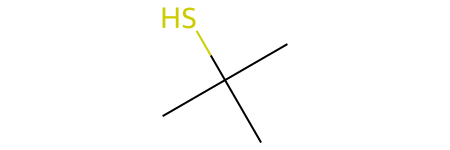

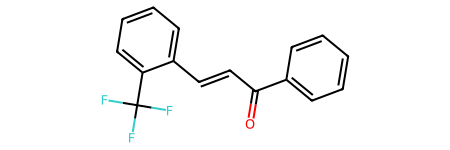

Observed ee: 73.0   Predicted ee: 65.75


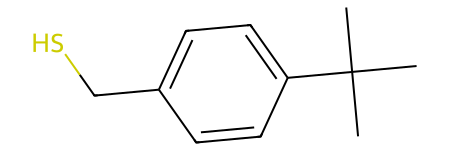

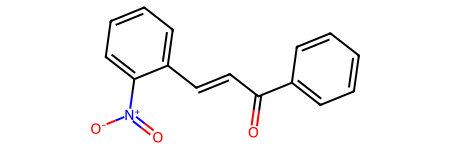

Observed ee: 27.0   Predicted ee: 50.0


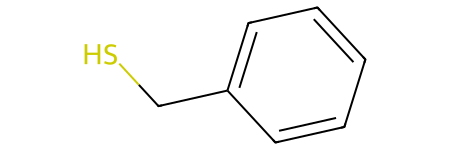

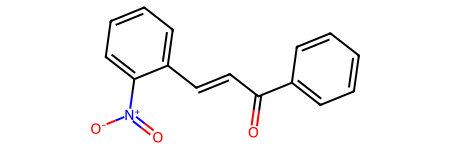

Observed ee: 56.0   Predicted ee: 65.75


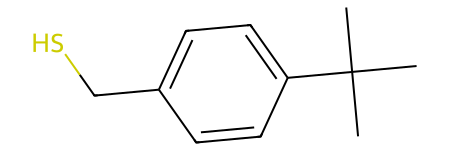

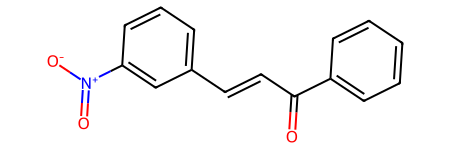

Observed ee: 92.0   Predicted ee: 92.0


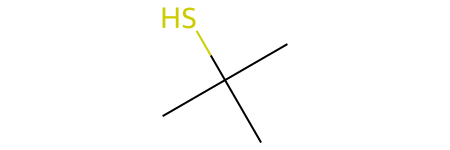

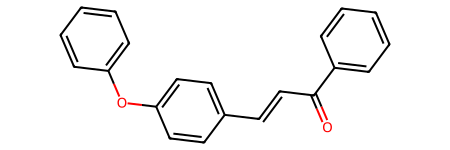

Observed ee: 79.5   Predicted ee: 80.0


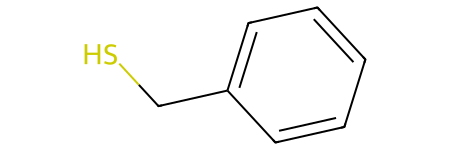

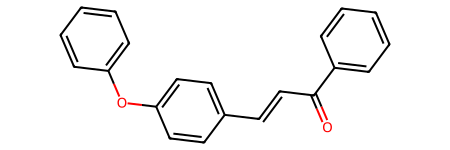

Observed ee: 47.0   Predicted ee: 65.75


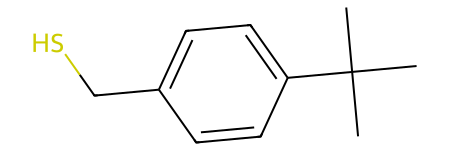

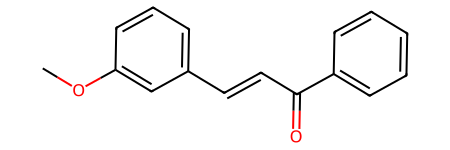

Observed ee: 88.0   Predicted ee: 91.5


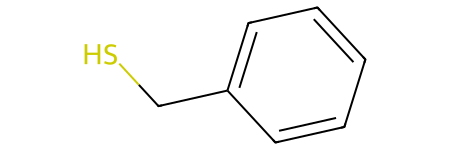

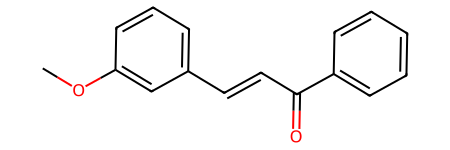

Observed ee: 65.0   Predicted ee: 65.75


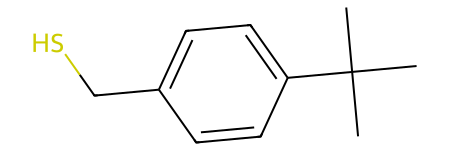

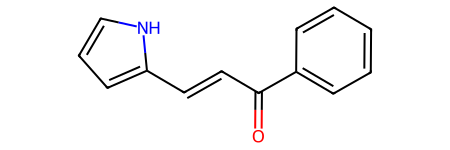

Observed ee: 43.5   Predicted ee: 74.0


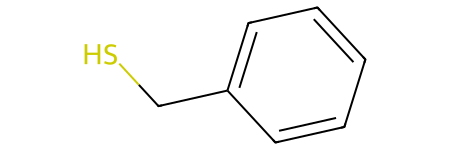

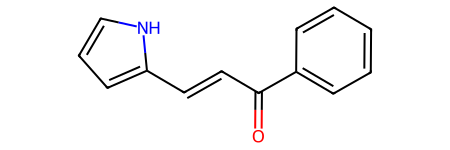

In [16]:

from rdkit import Chem
from IPython.display import display

for x in range(len(y_pred_val)):
    print("Observed ee: " + str(data['ee'][x]) + '   ' + "Predicted ee: " + str(y_pred_val[x]))
    mol = Chem.MolFromSmiles(val_df['SMILES_tiol'][x])
    display(mol)
    mol = Chem.MolFromSmiles(val_df['SMILES_chalkon'][x])
    display(mol)


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.spatial import Delaunay
import warnings
warnings.filterwarnings('ignore')


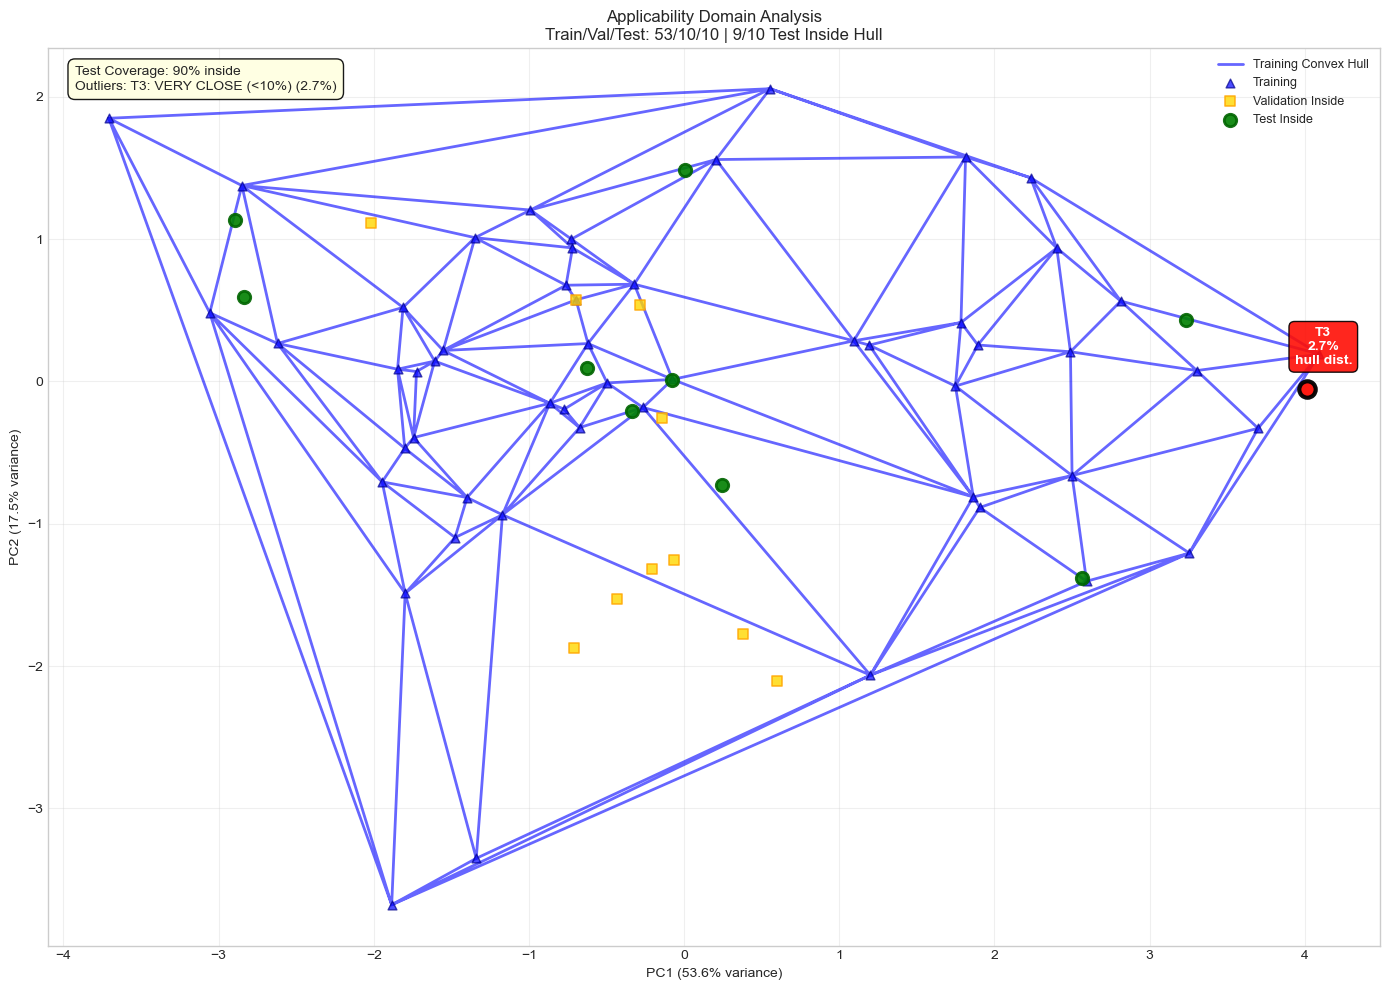

Outlier Analysis:
  T3: VERY CLOSE (<10%) (2.7%)

Summary: 9/10 test points inside hull (90.0%)
Detailed outlier info: {'T3': {'dist_to_hull': np.float64(0.05365692148388656), 'dist_to_edge': np.float64(0.05365692148388656), 'dist_to_vertex': np.float64(0.2562645011974097), 'hull_radius': np.float64(1.999234642114432), 'relative_dist_%': np.float64(2.6838731359285517)}}


In [18]:
def analyze_applicability_detailed(X_train, X_val, X_test):
    """Single plot version"""
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test) 
    
    pca = PCA(n_components=2)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    from scipy.spatial import Delaunay
    tri = Delaunay(X_train_pca)
    
    # Masks
    val_inside_mask = tri.find_simplex(X_val_pca) >= 0
    test_inside_mask = tri.find_simplex(X_test_pca) >= 0

    # Distance calculation
    def point_to_hull_distance(point, tri, X_train_pca):
        """Stable distance to convex hull"""
        min_dist = np.inf
        
        # 1. To vertices
        dist_vertices = np.min(np.linalg.norm(X_train_pca - point, axis=1))
        
        # 2. To edges
        min_edge_dist = np.inf
        for simplex in tri.simplices:
            for edge in [[0,1], [1,2], [2,0]]:
                p1 = X_train_pca[simplex[edge[0]]]
                p2 = X_train_pca[simplex[edge[1]]]
                
                edge_vec = p2 - p1
                point_vec = point - p1
                edge_len2 = np.dot(edge_vec, edge_vec)
                
                if edge_len2 != 0:
                    proj = np.dot(point_vec, edge_vec) / edge_len2
                    proj = np.clip(proj, 0, 1)
                    closest = p1 + proj * edge_vec
                    dist = np.linalg.norm(point - closest)
                    min_edge_dist = min(min_edge_dist, dist)
                else:
                    min_edge_dist = min(min_edge_dist, np.linalg.norm(point - p1))
        
        center = np.mean(X_train_pca, axis=0)
        hull_radius = np.mean(np.linalg.norm(X_train_pca - center, axis=1))
        
        total_min_dist = min(dist_vertices, min_edge_dist)
        
        return {
            'dist_to_hull': total_min_dist,
            'dist_to_edge': min_edge_dist,
            'dist_to_vertex': dist_vertices,
            'hull_radius': hull_radius,
            'relative_dist_%': (total_min_dist / hull_radius) * 100
        }

    # Analyze outliers
    outlier_info = {}
    outlier_descriptions = []
    for i, is_inside in enumerate(test_inside_mask):
        if not is_inside:
            info = point_to_hull_distance(X_test_pca[i], tri, X_train_pca)
            outlier_info[f'T{i}'] = info
            
            # English classification
            rel_dist = info['relative_dist_%']
            if rel_dist < 10:
                desc = "VERY CLOSE (<10%)"
            elif rel_dist < 25:
                desc = "CLOSE (10-25%)"
            else:
                desc = "FAR (>25%)"
            
            outlier_descriptions.append(f"T{i}: {desc} ({rel_dist:.1f}%)")

    # SINGLE PLOT - FULL FEATURES
    plt.figure(figsize=(14, 10))
    
    # Convex hull
    plt.triplot(X_train_pca[:, 0], X_train_pca[:, 1], tri.simplices, 
                'b-', alpha=0.6, linewidth=2, label='Training Convex Hull')

    # Training points
    plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c='blue', s=40, 
                alpha=0.7, marker='^', edgecolors='darkblue', label='Training')

    # Validation points
    plt.scatter(X_val_pca[val_inside_mask, 0], X_val_pca[val_inside_mask, 1], 
                c='gold', s=60, marker='s', alpha=0.8, 
                edgecolors='orange', label='Validation Inside', linewidth=1.2)
    if np.any(~val_inside_mask):
        plt.scatter(X_val_pca[~val_inside_mask, 0], X_val_pca[~val_inside_mask, 1], 
                    c='orange', s=60, marker='s', alpha=0.8, 
                    edgecolors='darkorange', label='Validation Outside', linewidth=1.2)

    # Test inside
    plt.scatter(X_test_pca[test_inside_mask, 0], X_test_pca[test_inside_mask, 1], 
                c='green', s=80, alpha=0.9, edgecolors='darkgreen', 
                label='Test Inside', linewidth=2)

    # Test outside WITH DISTANCES
    test_outside_idx = np.where(~test_inside_mask)[0]
    for i, idx in enumerate(test_outside_idx):
        dist_pct = outlier_info[f'T{idx}']['relative_dist_%']
        color_intensity = min(dist_pct / 30, 1)
        color = (1, color_intensity*0.6, color_intensity*0.2)  # Red gradient
        
        plt.scatter(X_test_pca[idx, 0], X_test_pca[idx, 1], 
                   c=color, s=140, alpha=0.95, edgecolors='black', linewidth=3)
        
        # Distance annotation
        plt.annotate(f'T{idx}\n{dist_pct:.1f}%\nhull dist.', 
                    (X_test_pca[idx, 0], X_test_pca[idx, 1]), 
                    xytext=(12, 18), textcoords='offset points', fontsize=10,
                    color='white', fontweight='bold', ha='center',
                    bbox=dict(boxstyle="round,pad=0.4", facecolor=color, alpha=0.9))

    # Title and labels
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    plt.title(f'Applicability Domain Analysis\n'
              f'Train/Val/Test: {len(X_train)}/{len(X_val)}/{len(X_test)} | '
              f'{np.sum(test_inside_mask)}/{len(test_inside_mask)} Test Inside Hull')
    
    # Legend with outlier summary
    legend_text = f"Test Coverage: {100*np.sum(test_inside_mask)/len(test_inside_mask):.0f}% inside"
    if outlier_descriptions:
        legend_text += f"\nOutliers: {', '.join(outlier_descriptions)}"
    
    plt.text(0.02, 0.98, legend_text, transform=plt.gca().transAxes, 
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle="round,pad=0.5", facecolor='lightyellow', alpha=0.9))
    
    plt.legend(loc='upper right', fontsize=9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Save publication-ready
    plt.savefig('applicability_domain_single_plot.pdf', dpi=300, bbox_inches='tight')
    plt.savefig('applicability_domain_single_plot.png', dpi=300, bbox_inches='tight')
    plt.savefig('applicability_domain_single_plot.svg', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Outlier Analysis:")
    for desc in outlier_descriptions:
        print(f"  {desc}")
    print(f"\nSummary: {np.sum(test_inside_mask)}/{len(test_inside_mask)} test points inside hull "
          f"({100*np.sum(test_inside_mask)/len(test_inside_mask):.1f}%)")
    
    return {
        'test_inside_mask': test_inside_mask,
        'val_inside_mask': val_inside_mask,
        'outlier_info': outlier_info,
        'outlier_descriptions': outlier_descriptions
    }

# USAGE:
result = analyze_applicability_detailed(X_train, data[list(X_train.columns)], X_test)
print("Detailed outlier info:", result['outlier_info'])


In [19]:
def analyze_applicability_heuristic(X_train, X_val, X_test, heuristic_threshold=0.1):
    """
    Analyzes Applicability Domain with Convex Hull and Distance Heuristic.
    
    Heuristic Logic:
    - Inside Hull -> In Domain
    - Outside Hull:
        - rel_dist = dist_to_hull / dist_to_centroid
        - if rel_dist < threshold -> In Domain (Extended)
        - if rel_dist >= threshold -> Out of Domain
    """
    
    # 1. Preprocessing & PCA
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test) 
    
    pca = PCA(n_components=2)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    # 2. Convex Hull (Delaunay)
    tri = Delaunay(X_train_pca)
    
    # Basic containment check
    val_inside_mask = tri.find_simplex(X_val_pca) >= 0
    test_inside_mask = tri.find_simplex(X_test_pca) >= 0
    
    # Geometric center of training data (Centroid)
    centroid_train = np.mean(X_train_pca, axis=0)

    # 3. Helper: Distance to Hull Calculation
    def get_hull_distance_info(point, tri, X_train_pca, centroid):
        # A. Distance to Hull (Geometric approach)
        # 1. To vertices
        dist_vertices = np.min(np.linalg.norm(X_train_pca - point, axis=1))
        
        # 2. To edges
        min_edge_dist = np.inf
        for simplex in tri.simplices:
            for edge in [[0,1], [1,2], [2,0]]:
                p1 = X_train_pca[simplex[edge[0]]]
                p2 = X_train_pca[simplex[edge[1]]]
                
                edge_vec = p2 - p1
                point_vec = point - p1
                edge_len2 = np.dot(edge_vec, edge_vec)
                
                if edge_len2 != 0:
                    proj = np.dot(point_vec, edge_vec) / edge_len2
                    proj = np.clip(proj, 0, 1)
                    closest = p1 + proj * edge_vec
                    dist = np.linalg.norm(point - closest)
                    min_edge_dist = min(min_edge_dist, dist)
                else:
                    min_edge_dist = min(min_edge_dist, np.linalg.norm(point - p1))
        
        r_d_hull = min(dist_vertices, min_edge_dist)
        
        # B. Distance to Geometric Center (Centroid)
        r_geometrical_center = np.linalg.norm(point - centroid)
        
        # C. Heuristic Ratio
        # Avoid division by zero
        rel_distance = r_d_hull / r_geometrical_center if r_geometrical_center > 1e-9 else 0
        
        return {
            'r_d_hull': r_d_hull,
            'r_geometrical_center': r_geometrical_center,
            'rel_distance': rel_distance
        }

    # 4. Analyze Test Points with Heuristic
    test_status = [] # 'inside', 'extended', 'out'
    outlier_details = {}
    
    for i in range(len(X_test_pca)):
        if test_inside_mask[i]:
            test_status.append('inside')
        else:
            # Calculate heuristic metrics
            info = get_hull_distance_info(X_test_pca[i], tri, X_train_pca, centroid_train)
            rel_dist = info['rel_distance']
            
            outlier_details[f'T{i}'] = info
            
            if rel_dist < heuristic_threshold:
                test_status.append('extended') # Outside hull but acceptable
            else:
                test_status.append('out') # Outside hull and unacceptable

    test_status = np.array(test_status)

    # 5. PLOTTING
    plt.figure(figsize=(12, 9))
    
    # A. Draw Hull
    plt.triplot(X_train_pca[:, 0], X_train_pca[:, 1], tri.simplices, 
                color='gray', alpha=0.4, linewidth=1, label='Training Convex Hull')

    # B. Plot Points
    # Training
    plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c='blue', s=30, 
                alpha=0.5, marker='o', label='Training Data')

    # Validation (Optional visualization)
    plt.scatter(X_val_pca[:, 0], X_val_pca[:, 1], c='orange', s=30, marker='s', alpha=0.6, label='Validation')

    # Test: Inside Hull (Safe)
    mask_in = test_status == 'inside'
    if np.any(mask_in):
        plt.scatter(X_test_pca[mask_in, 0], X_test_pca[mask_in, 1], 
                   c='green', s=80, alpha=0.9, edgecolors='darkgreen', 
                   label='Test: Inside Hull (Safe)')

    # Test: Extended Domain (Heuristic Acceptable)
    mask_ext = test_status == 'extended'
    if np.any(mask_ext):
        plt.scatter(X_test_pca[mask_ext, 0], X_test_pca[mask_ext, 1], 
                   c='yellowgreen', s=100, marker='D', alpha=0.9, edgecolors='black', 
                   label=f'Test: Extended Domain (rel_dist < {heuristic_threshold})')
        
        # Annotate extended points
        for idx in np.where(mask_ext)[0]:
            info = outlier_details[f'T{idx}']
            plt.annotate(f"T{idx}\n{info['rel_distance']:.2f}", 
                         (X_test_pca[idx, 0], X_test_pca[idx, 1]),
                         xytext=(0, 10), textcoords='offset points', ha='center', fontsize=8)

    # Test: Out of Domain
    mask_out = test_status == 'out'
    if np.any(mask_out):
        plt.scatter(X_test_pca[mask_out, 0], X_test_pca[mask_out, 1], 
                   c='red', s=120, marker='X', alpha=0.9, edgecolors='black', 
                   label=f'Test: Out of Domain (rel_dist >= {heuristic_threshold})')

        # Annotate outliers
        for idx in np.where(mask_out)[0]:
            info = outlier_details[f'T{idx}']
            plt.annotate(f"T{idx}\n{info['rel_distance']:.2f}", 
                         (X_test_pca[idx, 0], X_test_pca[idx, 1]),
                         xytext=(0, 10), textcoords='offset points', ha='center', 
                         color='red', fontweight='bold', fontsize=9)

    # Plot Centroid
    plt.scatter(centroid_train[0], centroid_train[1], c='black', marker='+', s=200, linewidth=2, label='Train Centroid')

    # Formatting
    plt.title(f'Applicability Domain Analysis (Heuristic Threshold = {heuristic_threshold})\n'
              f'Total Test: {len(X_test)} | Safe: {np.sum(mask_in)} | '
              f'Extended: {np.sum(mask_ext)} | Outliers: {np.sum(mask_out)}')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
    plt.legend(loc='upper right', frameon=True, framealpha=0.9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Save
    plt.savefig('AD_heuristic_plot.png', dpi=300)
    plt.savefig('AD_heuristic_plot.svg', dpi=300)
    plt.show()

    # Text Summary
    print("-" * 50)
    print("HEURISTIC SUMMARY")
    print("-" * 50)
    print(f"Threshold (rel_distance): {heuristic_threshold}")
    print(f"Inside Hull (Safe):       {np.sum(mask_in)}")
    print(f"Extended Domain (Safe):   {np.sum(mask_ext)}")
    print(f"Out of Domain (Unsafe):   {np.sum(mask_out)}")
    print("-" * 50)
    
    if len(outlier_details) > 0:
        print("\nDetails for points outside hull:")
        print(f"{'ID':<5} | {'r_hull':<10} | {'r_center':<10} | {'rel_dist':<10} | {'Status'}")
        for idx_str, info in outlier_details.items():
            status = "EXTENDED" if info['rel_distance'] < heuristic_threshold else "OUT"
            print(f"{idx_str:<5} | {info['r_d_hull']:.4f}     | {info['r_geometrical_center']:.4f}     | {info['rel_distance']:.4f}     | {status}")

    return {
        'test_status': test_status,
        'outlier_details': outlier_details,
        'mask_in': mask_in,
        'mask_extended': mask_ext,
        'mask_out': mask_out
    }

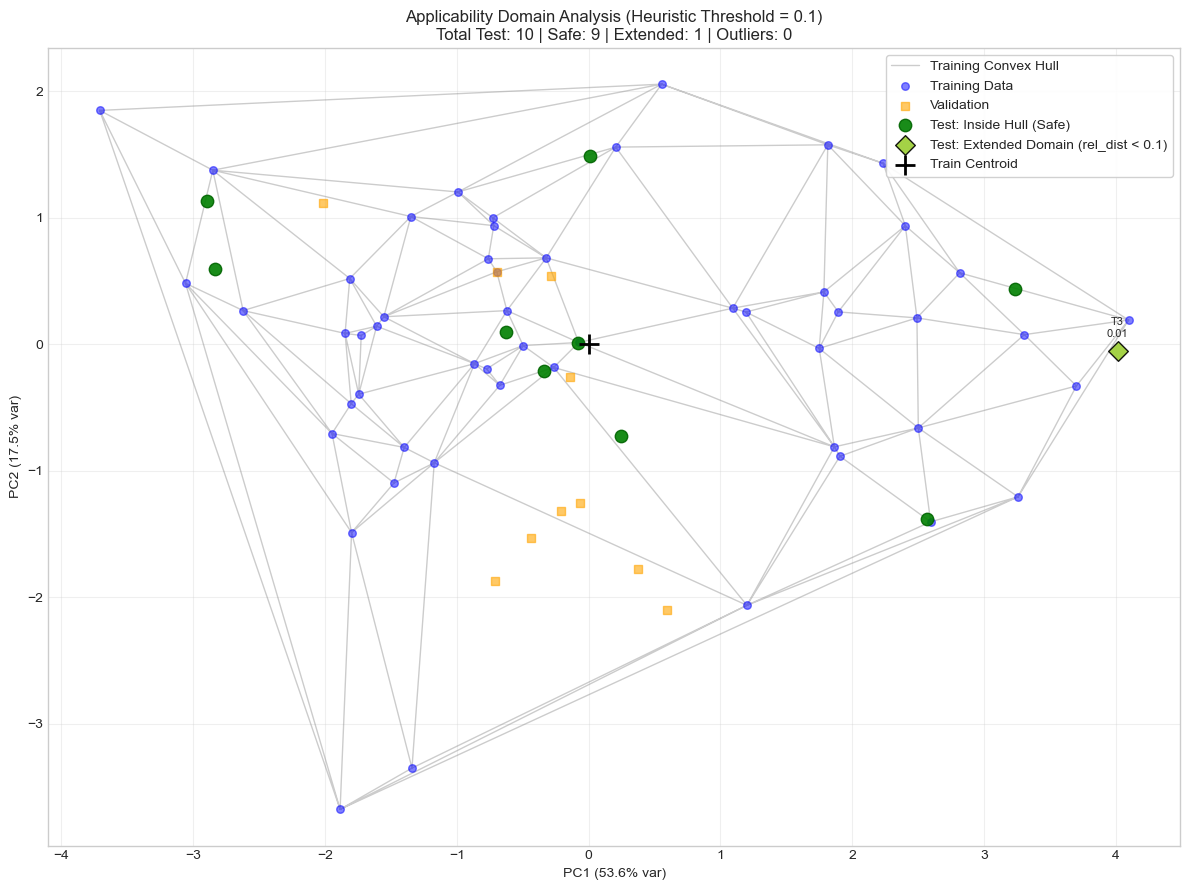

--------------------------------------------------
HEURISTIC SUMMARY
--------------------------------------------------
Threshold (rel_distance): 0.1
Inside Hull (Safe):       9
Extended Domain (Safe):   1
Out of Domain (Unsafe):   0
--------------------------------------------------

Details for points outside hull:
ID    | r_hull     | r_center   | rel_dist   | Status
T3    | 0.0537     | 4.0127     | 0.0134     | EXTENDED


In [20]:
result = analyze_applicability_heuristic(X_train, data[list(X_train.columns)], X_test, heuristic_threshold=0.1)

In [21]:
CONFIG = {
    # Data file
    'data': './Data/Exp_verification_III_modyfikacja_10struktur.xlsx',
    'target_col': 'ee',
    'name': 'validation_set',
    'mode': 'validation',
    'output_dir': './Data/'
}

In [22]:
# ============================================================================
# SECTION 3: LOAD DATA & CALCULATE ALL DESCRIPTORS
# ============================================================================

print('\n' + "█"*75)
print("█" + " STEP 1: LOAD DATA & CALCULATE ALL DESCRIPTORS ".center(73) + "█")
print("█"*75)

print(f"\nLoading data from: {CONFIG['data']}")
print(f"Calculating all descriptors: Mordred, Morgan, CircuS, ChemBERTa, Sterimol, Electronic")
print(f"This may take 5-15 minutes depending on dataset size...")

try:
    # Calculate ALL descriptors (full set)
    data = prepare_data(
        CONFIG['data'],
        CONFIG['target_col'],
        CONFIG['name'],
        CONFIG['mode'],
        CONFIG['output_dir'],
       
    )
    
    print(f"\n Data loaded and ALL descriptors calculated")
    print(f"  Total samples: {data.shape[0]}")
    print(f"  Total features: {data.shape[1]-1} (+ target)")
    print(f"  Target range: [{data[CONFIG['target_col']].min():.1f}, {data[CONFIG['target_col']].max():.1f}]")
    print(f"  Target mean: {data[CONFIG['target_col']].mean():.2f}")
    print(f"  Target std: {data[CONFIG['target_col']].std():.2f}")
    
except Exception as e:
    print(f"\n Error loading data: {e}")
    print(f"\n  Try these solutions:")
    print(f"  1. Check if {CONFIG['data']} exists")
    print(f"  2. Verify path is correct (relative or absolute)")
    print(f"  3. Check if models_creation.py is accessible")
    raise


███████████████████████████████████████████████████████████████████████████
█              STEP 1: LOAD DATA & CALCULATE ALL DESCRIPTORS              █
███████████████████████████████████████████████████████████████████████████

Loading data from: ./Data/Exp_verification_III_modyfikacja_10struktur.xlsx
Calculating all descriptors: Mordred, Morgan, CircuS, ChemBERTa, Sterimol, Electronic
This may take 5-15 minutes depending on dataset size...

LOADING DATA FOR UNIFIED DESCRIPTOR CALCULATION
  DESCRIPTOR PIPELINE:
 Mordred: True
 Morgan FP: True
 Sterimol + Electronic: True
 ChemBERTa: False
 CircuS: True
 ChyLine: True

---------------------------------------------------------------------------
Calculating/Cleaning descriptors ...
---------------------------------------------------------------------------
SUCCESS: Loaded CLEANED descriptors from Data\molecular_descriptors_cleaned_validation_set_.parquet
Shape: (10, 4110)
Returning: full descriptor set

 Data loaded and ALL descriptors 

In [23]:
data[list(X_train.columns)]

,IC1,GATS6are,ATSC1c,CIC1,GATS4d,PEOE_VSA6,SMR_VSA6
0,2.998636,1.745564,-0.280241,2.524926,0.687612,75.378168,0.000000
1,3.030130,1.144754,-0.093586,2.827851,0.757041,87.501249,0.000000
2,2.653997,1.516895,-0.085387,2.869565,1.036497,72.796405,0.000000
3,3.030130,1.297944,-0.094609,2.827851,0.745395,93.577269,0.000000
4,2.694069,1.349328,-0.225428,3.060819,0.637226,87.510902,0.000000
5,2.318135,1.291567,-0.214232,3.463224,1.038387,97.071526,0.000000
6,2.919148,1.154677,-0.177539,2.987743,0.766020,93.577269,7.109798
7,2.634762,1.453940,-0.169340,2.950201,1.035315,78.872425,7.109798
8,3.047159,1.303744,-0.168693,2.707728,0.696532,75.368515,0.000000
9,2.680262,1.841973,-0.160494,2.712055,0.940182,60.663671,0.000000


In [24]:
y_pred_exp = model.predict(data[list(X_train.columns)])

In [25]:
# Calculate metrics for the validation set
exp_r2 = r2_score(data['ee'], y_pred_exp)
exp_rmse = np.sqrt(mean_squared_error(data['ee'], y_pred_exp))

In [26]:
print("╔═════════════════╦═══════════════════════════╗")
print("║   Metric        ║  Validation Set           ║")
print("╠═════════════════╬═══════════════════════════╣")
print(f"║ R² (R-squared)  ║   {exp_r2:.4f}                  ║")
print(f"║ RMSE            ║   {exp_rmse:.2f}                   ║")
print("╚═════════════════╩═══════════════════════════╝")

╔═════════════════╦═══════════════════════════╗
║   Metric        ║  Validation Set           ║
╠═════════════════╬═══════════════════════════╣
║ R² (R-squared)  ║   0.4849                  ║
║ RMSE            ║   14.04                   ║
╚═════════════════╩═══════════════════════════╝


In [27]:


for x in range(len(y_pred_exp)):

    print("Observed ee: " + str(data['ee'][x]) + '   ' + "Predicted ee: " +str(y_pred_exp[x]))

Observed ee: 66.0   Predicted ee: 65.75
Observed ee: 73.0   Predicted ee: 65.75
Observed ee: 27.0   Predicted ee: 50.0
Observed ee: 56.0   Predicted ee: 65.75
Observed ee: 92.0   Predicted ee: 92.0
Observed ee: 79.5   Predicted ee: 80.0
Observed ee: 47.0   Predicted ee: 65.75
Observed ee: 88.0   Predicted ee: 91.5
Observed ee: 65.0   Predicted ee: 65.75
Observed ee: 43.5   Predicted ee: 74.0


In [28]:
exp_data = './Data/Exp_verification_III_modyfikacja_10struktur.xlsx'


# Load the datasets
exp_df = pd.read_excel(exp_data)
exp_df.head(1)

,l.p,SMILES_chalkon,SMILES_tiol,SMILES_produkt,experiment_ee,ee
0,26,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2C(F)(F)F,SC(C)(C)C,O=C(C1=CC=CC=C1)C[C@H](SC(C)(C)C)C2=CC=CC=C2C(...,66.0,66.0


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def analyze_applicability_heuristic(X_train, X_val, X_test, heuristic_threshold=0.1):
    """
    Analyzes Applicability Domain with Convex Hull and Distance Heuristic.
    Returns dictionaries containing processed DataFrames for Experimental (Val) and Test sets,
    printing indices of molecules outside the safe domain.
    """
    
    # 1. Preprocessing & PCA
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test) 
    
    pca = PCA(n_components=2)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    # 2. Convex Hull (Delaunay) on Training Data
    tri = Delaunay(X_train_pca)
    centroid_train = np.mean(X_train_pca, axis=0)

    # 3. Helper: Distance to Hull Calculation
    def get_hull_distance_info(point, tri, X_train_pca, centroid):
        # A. Distance to Hull (Geometric approach)
        dist_vertices = np.min(np.linalg.norm(X_train_pca - point, axis=1))
        
        min_edge_dist = np.inf
        for simplex in tri.simplices:
            for edge in [[0,1], [1,2], [2,0]]:
                p1 = X_train_pca[simplex[edge[0]]]
                p2 = X_train_pca[simplex[edge[1]]]
                
                edge_vec = p2 - p1
                point_vec = point - p1
                edge_len2 = np.dot(edge_vec, edge_vec)
                
                if edge_len2 != 0:
                    proj = np.dot(point_vec, edge_vec) / edge_len2
                    proj = np.clip(proj, 0, 1)
                    closest = p1 + proj * edge_vec
                    dist = np.linalg.norm(point - closest)
                    min_edge_dist = min(min_edge_dist, dist)
                else:
                    min_edge_dist = min(min_edge_dist, np.linalg.norm(point - p1))
        
        r_d_hull = min(dist_vertices, min_edge_dist)
        
        # B. Distance to Geometric Center (Centroid)
        r_geometrical_center = np.linalg.norm(point - centroid)
        
        # C. Heuristic Ratio
        rel_distance = r_d_hull / r_geometrical_center if r_geometrical_center > 1e-9 else 0
        
        return rel_distance

    # 4. Universal Function to Process Any Dataset
    def process_dataset(X_data, X_pca_data, dataset_name="Data"):
        if isinstance(X_data, pd.DataFrame):
            df_out = X_data.copy()
            
            indices = X_data.index.tolist()
        else:
            df_out = pd.DataFrame(X_data)
            indices = list(range(len(X_data)))
            
        is_inside = tri.find_simplex(X_pca_data) >= 0
        
        status_list = []
        rel_dist_list = []
        
        for i in range(len(X_pca_data)):
            if is_inside[i]:
                status_list.append('Inside Hull')
                rel_dist_list.append(0.0) 
            else:
                rel_dist = get_hull_distance_info(X_pca_data[i], tri, X_train_pca, centroid_train)
                rel_dist_list.append(rel_dist)
                
                if rel_dist < heuristic_threshold:
                    status_list.append('Extended Domain')
                else:
                    status_list.append('Out of Domain')
        
        df_out['AD_Status'] = status_list
        df_out['Rel_Distance'] = rel_dist_list
        # Dodajemy kolumnę pomocniczą z indeksem do łatwego dostępu
        df_out['Original_Index'] = indices
        
        return df_out, np.array(status_list)

    # 5. Apply Logic
    print("Processing Experimental Data...")
    X_val_df, val_statuses = process_dataset(X_val, X_val_pca, "Experimental")
    
    print("Processing Test Data...")
    X_test_df, test_statuses = process_dataset(X_test, X_test_pca, "Test")

    # 6. PLOTTING
    plt.figure(figsize=(12, 9))
    
    plt.triplot(X_train_pca[:, 0], X_train_pca[:, 1], tri.simplices, color='gray', alpha=0.4)
    plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c='blue', alpha=0.3, label='Training Data')
    plt.scatter(centroid_train[0], centroid_train[1], c='black', marker='+', s=200, label='Centroid')

    style_map = {
        'Inside Hull':     {'c': 'green', 'm': 'o', 'alpha': 0.6},
        'Extended Domain': {'c': 'orange', 'm': 'D', 'alpha': 0.8},
        'Out of Domain':   {'c': 'red',   'm': 'X', 'alpha': 0.9}
    }

    # Helper function to plot and annotate
    def plot_subset(df, pca_data, label_prefix, marker_style):
        for status in style_map:
            mask = df['AD_Status'] == status
            if mask.any():
                plt.scatter(pca_data[mask, 0], pca_data[mask, 1], 
                            c=style_map[status]['c'], marker=marker_style, s=60, edgecolors='black',
                            label=f'{label_prefix}: {status}')
                
                # Annotation for non-Inside points
                if status in ['Out of Domain', 'Extended Domain']:
                    idxs = np.where(mask)[0]
                    for idx in idxs:
                        dist = df.iloc[idx]['Rel_Distance']
                        mol_idx = df.iloc[idx]['Original_Index']
                        
                        #"Index: Distance annotation format"
                        label_text = f"#{mol_idx}\n{dist:.2f}"
                        
                        plt.annotate(label_text, 
                                     (pca_data[idx, 0], pca_data[idx, 1]),
                                     xytext=(5, 5), textcoords='offset points', 
                                     fontsize=8, fontweight='bold', color='black',
                                     bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6))

    plot_subset(X_val_df, X_val_pca, "Exp", 's')
    plot_subset(X_test_df, X_test_pca, "Test", 'P')

    plt.title(f'Applicability Domain (Threshold={heuristic_threshold})')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('AD_heuristic_plot_EXP.svg', dpi=300)
    plt.show()

    # 7. Summary Print with Indices
    def print_outliers(df, name):
        print(f"\n--- Detailed Report: {name} Set ---")
        counts = df['AD_Status'].value_counts()
        print(counts)
        
        for status in ['Extended Domain', 'Out of Domain']:
            subset = df[df['AD_Status'] == status]
            if not subset.empty:
                print(f"\n[{status}] Molecules (Index -> Rel_Distance):")
                for _, row in subset.iterrows():
                    print(f"  - Index {row['Original_Index']}: {row['Rel_Distance']:.4f}")
            else:
                print(f"\n[{status}]: None")

    print_outliers(X_val_df, "Experimental")
    print_outliers(X_test_df, "Test")

    return {
        'exp_results_df': X_val_df,
        'test_results_df': X_test_df
    }


In [30]:
print("Test-set indices:")
print(X_test.index.tolist())

Test-set indices:
[11, 13, 41, 52, 59, 31, 18, 27, 29, 56]


In [31]:
X_test

,IC1,GATS6are,ATSC1c,CIC1,GATS4d,PEOE_VSA6,SMR_VSA6
index,,,,,,,
11,2.215431,1.700711,-0.084079,3.428425,1.009779,103.137893,0.000000
13,2.138687,1.302255,-0.081634,3.446276,1.042077,109.223566,0.000000
41,2.719416,1.389052,-0.201783,2.638136,0.824339,66.739691,0.000000
52,3.392153,1.191591,-0.545758,2.415202,1.005541,52.337799,19.972449
59,2.926247,0.176270,-0.069788,1.881108,0.631169,36.407855,0.000000
31,2.579349,1.702707,-0.089432,2.778203,0.975070,66.730038,0.000000
18,2.602357,0.800758,-0.274570,2.952232,0.847059,78.872425,0.000000
27,2.653997,1.188641,-0.089328,2.869565,0.875264,66.739691,0.000000
29,2.634762,0.933649,-0.172214,2.950201,1.121591,78.862772,7.109798


Processing Experimental Data...
Processing Test Data...


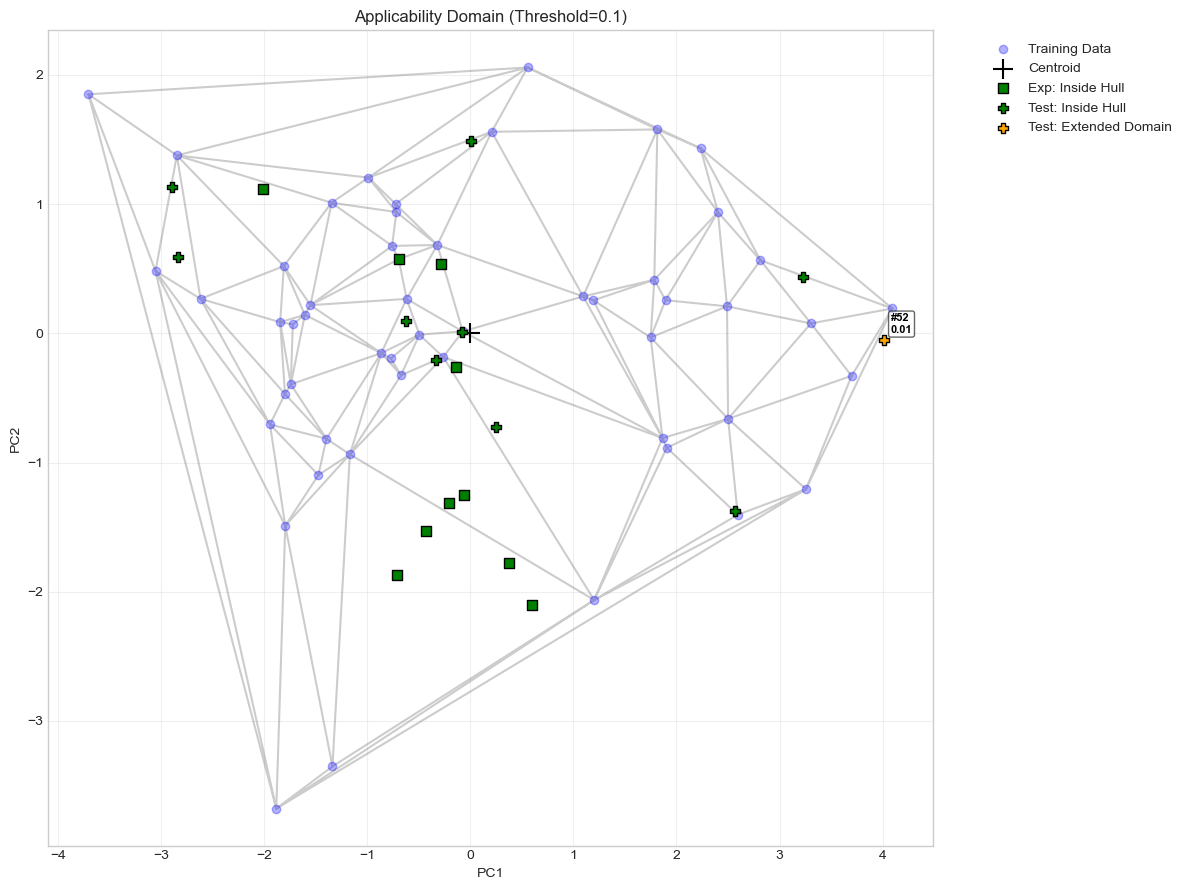


--- Detailed Report: Experimental Set ---
AD_Status
Inside Hull    10
Name: count, dtype: int64

[Extended Domain]: None

[Out of Domain]: None

--- Detailed Report: Test Set ---
AD_Status
Inside Hull        9
Extended Domain    1
Name: count, dtype: int64

[Extended Domain] Molecules (Index -> Rel_Distance):
  - Index 52: 0.0134

[Out of Domain]: None


In [30]:
result = analyze_applicability_heuristic(X_train, data[list(X_train.columns)], X_test, heuristic_threshold=0.1)

In [31]:
result['exp_results_df']

,IC1,GATS6are,ATSC1c,CIC1,GATS4d,PEOE_VSA6,SMR_VSA6,AD_Status,Rel_Distance,Original_Index
0,2.998636,1.745564,-0.280241,2.524926,0.687612,75.378168,0.000000,Inside Hull,0.0,0
1,3.030130,1.144754,-0.093586,2.827851,0.757041,87.501249,0.000000,Inside Hull,0.0,1
2,2.653997,1.516895,-0.085387,2.869565,1.036497,72.796405,0.000000,Inside Hull,0.0,2
3,3.030130,1.297944,-0.094609,2.827851,0.745395,93.577269,0.000000,Inside Hull,0.0,3
4,2.694069,1.349328,-0.225428,3.060819,0.637226,87.510902,0.000000,Inside Hull,0.0,4
5,2.318135,1.291567,-0.214232,3.463224,1.038387,97.071526,0.000000,Inside Hull,0.0,5
6,2.919148,1.154677,-0.177539,2.987743,0.766020,93.577269,7.109798,Inside Hull,0.0,6
7,2.634762,1.453940,-0.169340,2.950201,1.035315,78.872425,7.109798,Inside Hull,0.0,7
8,3.047159,1.303744,-0.168693,2.707728,0.696532,75.368515,0.000000,Inside Hull,0.0,8
9,2.680262,1.841973,-0.160494,2.712055,0.940182,60.663671,0.000000,Inside Hull,0.0,9


In [32]:
result['test_results_df']

,IC1,GATS6are,ATSC1c,CIC1,GATS4d,PEOE_VSA6,SMR_VSA6,AD_Status,Rel_Distance,Original_Index
index,,,,,,,,,,
11,2.215431,1.700711,-0.084079,3.428425,1.009779,103.137893,0.000000,Inside Hull,0.000000,11
13,2.138687,1.302255,-0.081634,3.446276,1.042077,109.223566,0.000000,Inside Hull,0.000000,13
41,2.719416,1.389052,-0.201783,2.638136,0.824339,66.739691,0.000000,Inside Hull,0.000000,41
52,3.392153,1.191591,-0.545758,2.415202,1.005541,52.337799,19.972449,Extended Domain,0.013372,52
59,2.926247,0.176270,-0.069788,1.881108,0.631169,36.407855,0.000000,Inside Hull,0.000000,59
31,2.579349,1.702707,-0.089432,2.778203,0.975070,66.730038,0.000000,Inside Hull,0.000000,31
18,2.602357,0.800758,-0.274570,2.952232,0.847059,78.872425,0.000000,Inside Hull,0.000000,18
27,2.653997,1.188641,-0.089328,2.869565,0.875264,66.739691,0.000000,Inside Hull,0.000000,27
29,2.634762,0.933649,-0.172214,2.950201,1.121591,78.862772,7.109798,Inside Hull,0.000000,29


In [33]:
fig = exp_df
fig['predicted_ee'] = y_pred_exp
fig.head()

,l.p,SMILES_chalkon,SMILES_tiol,SMILES_produkt,experiment_ee,ee,predicted_ee
0,26,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2C(F)(F)F,SC(C)(C)C,O=C(C1=CC=CC=C1)C[C@H](SC(C)(C)C)C2=CC=CC=C2C(...,66.0,66.0,65.75
1,28,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2[N+]([O-])=O,SCC1=CC=C(C(C)(C)C)C=C1,O=C(C1=CC=CC=C1)C[C@H](SCC2=CC=C(C(C)(C)C)C=C2...,73.0,73.0,65.75
2,30,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2[N+]([O-])=O,SCC1=CC=CC=C1,O=C(C1=CC=CC=C1)C[C@H](SCC2=CC=CC=C2)C3=CC=CC(...,27.0,27.0,50.00
3,31,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC([N+]([O-])=O)=C2,SCC1=CC=C(C(C)(C)C)C=C1,O=C(C1=CC=CC=C1)C[C@H](SCC2=CC=C(C(C)(C)C)C=C2...,56.0,56.0,65.75
4,32,O=C(C1=CC=CC=C1)/C=C/C2=CC=C(OC3=CC=CC=C3)C=C2,SC(C)(C)C,O=C(C1=CC=CC=C1)C[C@H](SC(C)(C)C)C2=CC=C(OC3=C...,92.0,92.0,92.00


In [34]:
fig['AD_Status'] = result['exp_results_df']['AD_Status']
fig.head()

,l.p,SMILES_chalkon,SMILES_tiol,SMILES_produkt,experiment_ee,ee,predicted_ee,AD_Status
0,26,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2C(F)(F)F,SC(C)(C)C,O=C(C1=CC=CC=C1)C[C@H](SC(C)(C)C)C2=CC=CC=C2C(...,66.0,66.0,65.75,Inside Hull
1,28,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2[N+]([O-])=O,SCC1=CC=C(C(C)(C)C)C=C1,O=C(C1=CC=CC=C1)C[C@H](SCC2=CC=C(C(C)(C)C)C=C2...,73.0,73.0,65.75,Inside Hull
2,30,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2[N+]([O-])=O,SCC1=CC=CC=C1,O=C(C1=CC=CC=C1)C[C@H](SCC2=CC=CC=C2)C3=CC=CC(...,27.0,27.0,50.00,Inside Hull
3,31,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC([N+]([O-])=O)=C2,SCC1=CC=C(C(C)(C)C)C=C1,O=C(C1=CC=CC=C1)C[C@H](SCC2=CC=C(C(C)(C)C)C=C2...,56.0,56.0,65.75,Inside Hull
4,32,O=C(C1=CC=CC=C1)/C=C/C2=CC=C(OC3=CC=CC=C3)C=C2,SC(C)(C)C,O=C(C1=CC=CC=C1)C[C@H](SC(C)(C)C)C2=CC=C(OC3=C...,92.0,92.0,92.00,Inside Hull


In [35]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D

def draw_molgrid_with_results(df, 
                              smiles_col='SMILES_tiol',
                              smiles_col_2='SMILES_chalkon',
                              obs_col='ee', 
                              pred_col='predicted_ee',
                              hull_col='AD_Status',
                              n_per_row=4, 
                              max_mols=100, 
                              img_size=(400, 400)):

    combined_mols = []
    legends = []
    
    df_subset = df.head(max_mols)
    
    for idx, row in df_subset.iterrows():

        smi1 = str(row[smiles_col])
        smi2 = str(row[smiles_col_2])
        
        combined_smi = f"{smi1}.{smi2}"
        mol = Chem.MolFromSmiles(combined_smi)
        
        if mol is not None:
            combined_mols.append(mol)
            
            obs = row[obs_col]
            pred = row[pred_col]
            hull = row[hull_col]
            error = abs(obs - pred)

            label = f"Obs: {obs:.1f} | Pred: {pred:.1f} | Err: {error:.1f}\nAD: {hull}"
            legends.append(label)
        else:
            print(f"Błąd konwersji SMILES na indeksie {idx}")

    dopts = rdMolDraw2D.MolDrawOptions()
    dopts.legendFontSize = 24  
    dopts.padding = 0.05
    dopts.bondLineWidth = 3
    
    img = Draw.MolsToGridImage(
        combined_mols, 
        molsPerRow=n_per_row, 
        subImgSize=img_size, 
        legends=legends,
        useSVG=True,
        drawOptions=dopts
    )
    
    return img

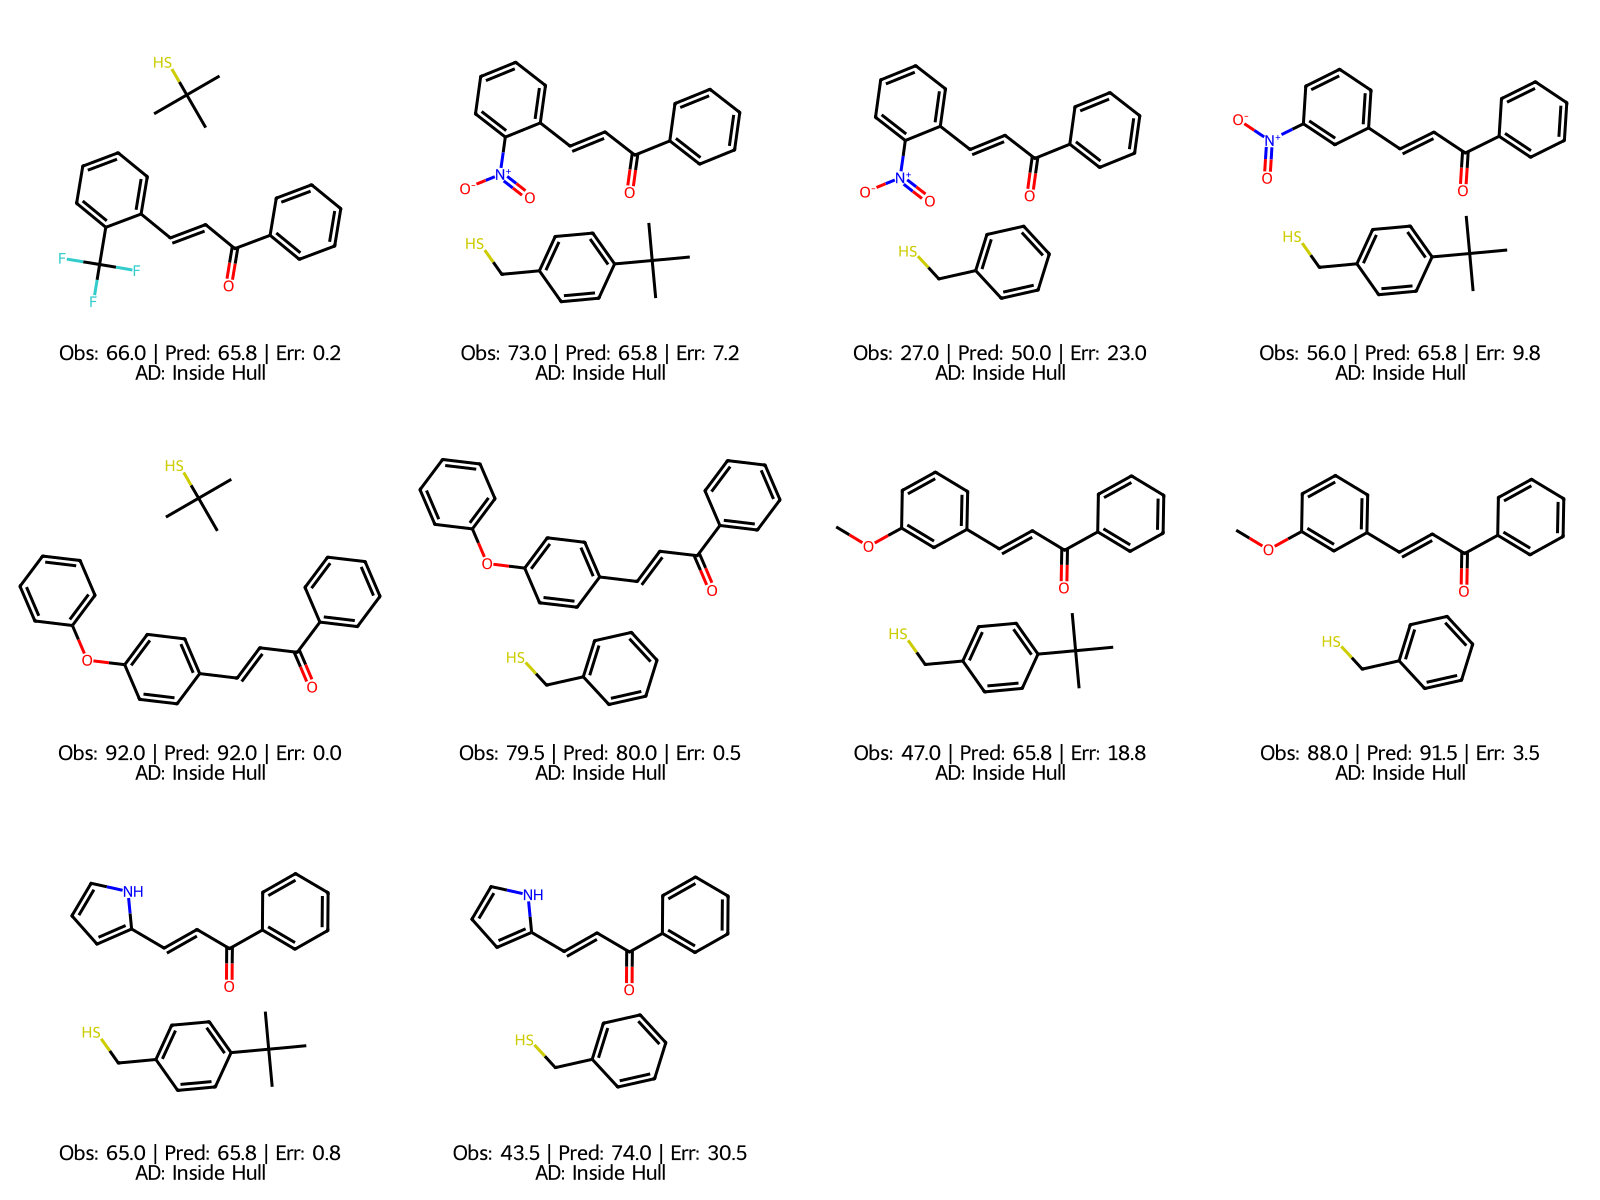

In [36]:
img = draw_molgrid_with_results(fig, max_mols=100)
display(img)

In [37]:
fig['AD_Status'] = result['exp_results_df']['AD_Status']
fig.head()

,l.p,SMILES_chalkon,SMILES_tiol,SMILES_produkt,experiment_ee,ee,predicted_ee,AD_Status
0,26,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2C(F)(F)F,SC(C)(C)C,O=C(C1=CC=CC=C1)C[C@H](SC(C)(C)C)C2=CC=CC=C2C(...,66.0,66.0,65.75,Inside Hull
1,28,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2[N+]([O-])=O,SCC1=CC=C(C(C)(C)C)C=C1,O=C(C1=CC=CC=C1)C[C@H](SCC2=CC=C(C(C)(C)C)C=C2...,73.0,73.0,65.75,Inside Hull
2,30,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2[N+]([O-])=O,SCC1=CC=CC=C1,O=C(C1=CC=CC=C1)C[C@H](SCC2=CC=CC=C2)C3=CC=CC(...,27.0,27.0,50.00,Inside Hull
3,31,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC([N+]([O-])=O)=C2,SCC1=CC=C(C(C)(C)C)C=C1,O=C(C1=CC=CC=C1)C[C@H](SCC2=CC=C(C(C)(C)C)C=C2...,56.0,56.0,65.75,Inside Hull
4,32,O=C(C1=CC=CC=C1)/C=C/C2=CC=C(OC3=CC=CC=C3)C=C2,SC(C)(C)C,O=C(C1=CC=CC=C1)C[C@H](SC(C)(C)C)C2=CC=C(OC3=C...,92.0,92.0,92.00,Inside Hull


In [38]:
fig['ee'][fig['AD_Status'] == 'Inside Hull']

0    66.0
1    73.0
2    27.0
3    56.0
4    92.0
5    79.5
6    47.0
7    88.0
8    65.0
9    43.5
Name: ee, dtype: float64

In [39]:
# Calculate metrics for the validation set
exp_r2 = r2_score(fig['ee'][fig['AD_Status'] == 'Inside Hull'], fig['predicted_ee'][fig['AD_Status'] == 'Inside Hull'])
exp_rmse = np.sqrt(mean_squared_error(fig['ee'][fig['AD_Status'] == 'Inside Hull'], fig['predicted_ee'][fig['AD_Status'] == 'Inside Hull']))

In [40]:
len(fig['ee'][fig['AD_Status'] == 'Inside Hull'])

10

In [41]:
print("╔═════════════════╦═══════════════════════════╗")
print("║   Metric        ║  Inside Hull Set           ║")
print("╠═════════════════╬═══════════════════════════╣")
print(f"║ R² (R-squared)  ║   {exp_r2:.4f}                  ║")
print(f"║ RMSE            ║   {exp_rmse:.2f}                   ║")
print("╚═════════════════╩═══════════════════════════╝")

╔═════════════════╦═══════════════════════════╗
║   Metric        ║  Inside Hull Set           ║
╠═════════════════╬═══════════════════════════╣
║ R² (R-squared)  ║   0.4849                  ║
║ RMSE            ║   14.04                   ║
╚═════════════════╩═══════════════════════════╝


In [43]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from scipy.spatial import Delaunay
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


from pathlib import Path

OUTPUT_DIR = Path(
    r"C:\Users\aleks\Documents\GitHub\asymmetric-catalysis-qspr-ml"
    r"\thia-Michael_regression\third_split\Kfold\substrate"
    r"\no_chemberta_Kfold_Review_1\Results\ReviewerValidation"
)

AD_OUTPUT_DIR = OUTPUT_DIR / "ApplicabilityDomain"
AD_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"AD output directory: {AD_OUTPUT_DIR}")

mpl.rcParams.update({
    "font.family": "Arial",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 10,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10.5,
    "ytick.labelsize": 10.5,
    "legend.fontsize": 8.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "axes.linewidth": 1.1,
})


def analyze_applicability_heuristic(
    X_train,
    X_val,
    X_test,
    heuristic_threshold=0.1,
    output_dir=AD_OUTPUT_DIR,
    figure_name="Fig_S_AD_heuristic",
):
    """
    PCA/Delaunay-based applicability-domain visualization.

    The current geometric heuristic is retained.
    Unique identifiers are assigned to validation and test observations:
    EXP-01, EXP-02, ... and TEST-01, TEST-02, ...

    Only Extended Domain and Out of Domain points are annotated.
    """

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # 1. Standardization and PCA fitted exclusively on training descriptors.
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    pca = PCA(n_components=2)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    # 2. Delaunay triangulation and training-set centroid in PCA space.
    tri = Delaunay(X_train_pca)
    centroid_train = np.mean(X_train_pca, axis=0)

    # 3. Retain your current distance heuristic.
    def get_hull_distance_info(point, tri, X_train_pca, centroid):
        dist_vertices = np.min(
            np.linalg.norm(X_train_pca - point, axis=1)
        )

        min_edge_dist = np.inf

        for simplex in tri.simplices:
            for edge in [[0, 1], [1, 2], [2, 0]]:
                p1 = X_train_pca[simplex[edge[0]]]
                p2 = X_train_pca[simplex[edge[1]]]

                edge_vec = p2 - p1
                point_vec = point - p1
                edge_len2 = np.dot(edge_vec, edge_vec)

                if edge_len2 != 0:
                    projection = np.dot(point_vec, edge_vec) / edge_len2
                    projection = np.clip(projection, 0, 1)
                    closest = p1 + projection * edge_vec
                    dist = np.linalg.norm(point - closest)
                    min_edge_dist = min(min_edge_dist, dist)
                else:
                    min_edge_dist = min(
                        min_edge_dist,
                        np.linalg.norm(point - p1),
                    )

        r_d_hull = min(dist_vertices, min_edge_dist)
        r_geometrical_center = np.linalg.norm(point - centroid)

        return (
            r_d_hull / r_geometrical_center
            if r_geometrical_center > 1e-9
            else 0.0
        )

    # 4. Process validation or development-comparison dataset.
    def process_dataset(
        X_data,
        X_pca_data,
        dataset_name,
        id_prefix,
    ):
        if isinstance(X_data, pd.DataFrame):
            df_out = X_data.copy()
            original_indices = X_data.index.astype(str).tolist()
        else:
            df_out = pd.DataFrame(X_data)
            original_indices = [str(i) for i in range(len(X_data))]

        is_inside = tri.find_simplex(X_pca_data) >= 0

        status_list = []
        relative_distance_list = []

        for i, point in enumerate(X_pca_data):
            if is_inside[i]:
                status_list.append("Inside Hull")
                relative_distance_list.append(0.0)
            else:
                relative_distance = get_hull_distance_info(
                    point,
                    tri,
                    X_train_pca,
                    centroid_train,
                )

                relative_distance_list.append(relative_distance)

                if relative_distance < heuristic_threshold:
                    status_list.append("Extended Domain")
                else:
                    status_list.append("Out of Domain")

        df_out["AD_ID"] = [
            f"{id_prefix}-{i + 1:02d}"
            for i in range(len(df_out))
        ]
        df_out["Original_Index"] = original_indices
        df_out["AD_Status"] = status_list
        df_out["Rel_Distance"] = relative_distance_list
        df_out["PC1"] = X_pca_data[:, 0]
        df_out["PC2"] = X_pca_data[:, 1]

        return df_out, np.asarray(status_list)

    print("Processing experimental/prospective validation data...")

    X_val_df, val_statuses = process_dataset(
        X_data=X_val,
        X_pca_data=X_val_pca,
        dataset_name="Experimental",
        id_prefix="EXP",
    )

    print("Processing development comparison/test data...")

    X_test_df, test_statuses = process_dataset(
        X_data=X_test,
        X_pca_data=X_test_pca,
        dataset_name="Test",
        id_prefix="TEST",
    )

    # 5. Publication-oriented visualization.
    fig, ax = plt.subplots(figsize=(9.0, 7.0))

    ax.triplot(
        X_train_pca[:, 0],
        X_train_pca[:, 1],
        tri.simplices,
        color="#A6A6A6",
        alpha=0.30,
        linewidth=0.7,
        zorder=1,
    )

    ax.scatter(
        X_train_pca[:, 0],
        X_train_pca[:, 1],
        color="#BDBDBD",
        edgecolor="white",
        linewidth=0.4,
        alpha=0.90,
        s=42,
        label="Training set",
        zorder=2,
    )

    ax.scatter(
        centroid_train[0],
        centroid_train[1],
        color="#1A1A1A",
        marker="+",
        s=145,
        linewidth=2.0,
        label="Training centroid",
        zorder=5,
    )

    style_map = {
        "Inside Hull": {
            "color": "#2E8B57",
            "marker": "o",
            "alpha": 0.75,
        },
        "Extended Domain": {
            "color": "#E69F00",
            "marker": "D",
            "alpha": 0.95,
        },
        "Out of Domain": {
            "color": "#C62828",
            "marker": "X",
            "alpha": 0.95,
        },
    }

    def plot_subset(df, label_prefix, marker_style):
        for status, style in style_map.items():
            mask = df["AD_Status"] == status

            if not mask.any():
                continue

            ax.scatter(
                df.loc[mask, "PC1"],
                df.loc[mask, "PC2"],
                color=style["color"],
                marker=marker_style,
                s=82,
                alpha=style["alpha"],
                edgecolor="black",
                linewidth=0.7,
                label=f"{label_prefix}: {status}",
                zorder=6,
            )

            # Annotate only points requiring structural interpretation.
            if status in ["Extended Domain", "Out of Domain"]:
                for _, row in df.loc[mask].iterrows():
                    label_text = (
                        f"{row['AD_ID']}\n"
                        f"{row['Rel_Distance']:.2f}"
                    )

                    ax.annotate(
                        label_text,
                        (row["PC1"], row["PC2"]),
                        xytext=(6, 6),
                        textcoords="offset points",
                        fontsize=8,
                        fontweight="bold",
                        color="#1A1A1A",
                        bbox=dict(
                            boxstyle="round,pad=0.20",
                            facecolor="white",
                            edgecolor="#A6A6A6",
                            linewidth=0.6,
                            alpha=0.92,
                        ),
                        zorder=8,
                    )

    plot_subset(
        X_val_df,
        label_prefix="Experimental",
        marker_style="s",
    )

    plot_subset(
        X_test_df,
        label_prefix="Comparison",
        marker_style="P",
    )

    ax.set_title(
        f"PCA-based applicability-domain visualization "
        f"(threshold = {heuristic_threshold:.2f})",
        fontweight="bold",
        pad=12,
    )

    ax.set_xlabel(
        f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)"
    )

    ax.set_ylabel(
        f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)"
    )

    ax.grid(True, color="#E6E6E6", linewidth=0.7, zorder=0)
    ax.tick_params(direction="out", width=1.0, length=4.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    handles, labels = ax.get_legend_handles_labels()
    unique_legend = dict(zip(labels, handles))

    ax.legend(
        unique_legend.values(),
        unique_legend.keys(),
        bbox_to_anchor=(1.02, 1.0),
        loc="upper left",
        frameon=False,
        fontsize=8.2,
    )

    fig.tight_layout()

    figure_base = output_dir / figure_name

    fig.savefig(
        figure_base.with_suffix(".pdf"),
        bbox_inches="tight",
    )

    fig.savefig(
        figure_base.with_suffix(".svg"),
        bbox_inches="tight",
    )

    fig.savefig(
        figure_base.with_suffix(".png"),
        dpi=600,
        bbox_inches="tight",
    )

    plt.show()

    # 6. Save complete tables for traceability.
    X_val_df.to_csv(
        output_dir / "AD_experimental_results.csv",
        index=True,
    )

    X_test_df.to_csv(
        output_dir / "AD_comparison_results.csv",
        index=True,
    )

    # 7. Compact printed summary.
    def print_outliers(df, name):
        print(f"\n--- {name}: AD status counts ---")
        display(df["AD_Status"].value_counts())

        outside_df = df.loc[
            df["AD_Status"].isin(
                ["Extended Domain", "Out of Domain"]
            ),
            [
                "AD_ID",
                "Original_Index",
                "AD_Status",
                "Rel_Distance",
            ],
        ].sort_values(
            ["AD_Status", "Rel_Distance"],
            ascending=[True, False],
        )

        if outside_df.empty:
            print("No Extended Domain or Out of Domain structures.")
        else:
            print(f"\n{name}: structures requiring interpretation")
            display(outside_df.round(4))

    print_outliers(X_val_df, "Experimental/prospective set")
    print_outliers(X_test_df, "Development comparison set")

    return {
        "exp_results_df": X_val_df,
        "test_results_df": X_test_df,
        "scaler": scaler,
        "pca": pca,
        "train_pca": X_train_pca,
        "val_pca": X_val_pca,
        "test_pca": X_test_pca,
    }

AD output directory: C:\Users\aleks\Documents\GitHub\asymmetric-catalysis-qspr-ml\thia-Michael_regression\third_split\Kfold\substrate\no_chemberta_Kfold_Review_1\Results\ReviewerValidation\ApplicabilityDomain


Processing experimental/prospective validation data...
Processing development comparison/test data...


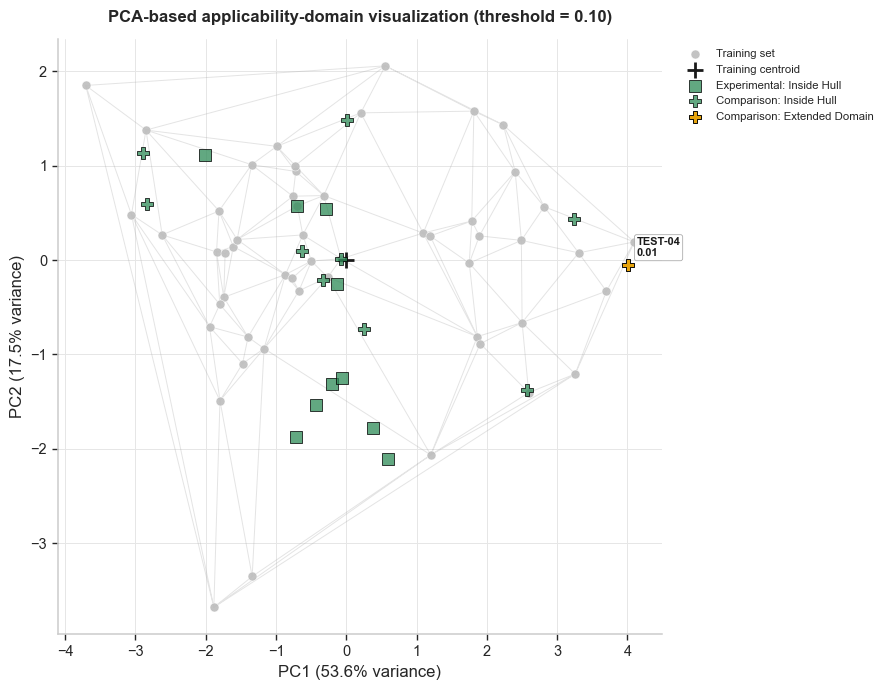


--- Experimental/prospective set: AD status counts ---


AD_Status
Inside Hull    10
Name: count, dtype: int64

No Extended Domain or Out of Domain structures.

--- Development comparison set: AD status counts ---


AD_Status
Inside Hull        9
Extended Domain    1
Name: count, dtype: int64


Development comparison set: structures requiring interpretation


,AD_ID,Original_Index,AD_Status,Rel_Distance
index,,,,
52,TEST-04,52,Extended Domain,0.0134


In [44]:
ad_results = analyze_applicability_heuristic(
    X_train=X_train,
    X_val=data[list(X_train.columns)],
    X_test=X_test,
    heuristic_threshold=0.10,
)
##X_train, data[list(X_train.columns)], X_test
X_val_ad = ad_results["exp_results_df"].copy()
X_test_ad = ad_results["test_results_df"].copy()

In [45]:
from pathlib import Path

import numpy as np
import pandas as pd

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D


def draw_molgrid_with_results(
    df,
    smiles_col="SMILES_tiol",
    smiles_col_2="SMILES_chalkon",
    obs_col="ee",
    pred_col="predicted_ee",
    hull_col="AD_Status",
    ad_id_col="AD_ID",
    distance_col="Rel_Distance",
    n_per_row=3,
    max_mols=100,
    img_size=(430, 360),
):
    """
    Draws paired thiol + chalcone structures and adds AD identifiers.

    The input dataframe should already contain:
    AD_ID, AD_Status, Rel_Distance, observed ee, predicted ee,
    SMILES_tiol, and SMILES_chalkon.
    """

    combined_mols = []
    legends = []

    status_order = {
        "Out of Domain": 0,
        "Extended Domain": 1,
        "Inside Hull": 2,
    }

    df_subset = df.copy()

    df_subset["_status_order"] = df_subset[hull_col].map(
        status_order
    )

    df_subset = df_subset.sort_values(
        ["_status_order", distance_col],
        ascending=[True, False],
    ).head(max_mols)

    for dataframe_index, row in df_subset.iterrows():
        thiol_smiles = str(row[smiles_col])
        chalcone_smiles = str(row[smiles_col_2])

        combined_smiles = f"{thiol_smiles}.{chalcone_smiles}"
        mol = Chem.MolFromSmiles(combined_smiles)

        if mol is None:
            print(
                "SMILES conversion error for "
                f"{row.get(ad_id_col, dataframe_index)}"
            )
            continue

        combined_mols.append(mol)

        observed = float(row[obs_col])
        predicted = float(row[pred_col])
        error = abs(observed - predicted)

        ad_id = str(row[ad_id_col])
        ad_status = str(row[hull_col])
        relative_distance = row.get(distance_col, np.nan)

        label = (
            f"{ad_id} | {ad_status}\n"
            f"Obs: {observed:.1f} | Pred: {predicted:.1f}\n"
            f"Abs. error: {error:.1f} | Rel. dist.: {relative_distance:.3f}"
        )

        legends.append(label)

    if not combined_mols:
        raise ValueError(
            "No valid molecules were generated for the molgrid."
        )

    draw_options = rdMolDraw2D.MolDrawOptions()
    draw_options.legendFontSize = 18
    draw_options.padding = 0.04
    draw_options.bondLineWidth = 2.5

    return Draw.MolsToGridImage(
        combined_mols,
        molsPerRow=n_per_row,
        subImgSize=img_size,
        legends=legends,
        useSVG=True,
        drawOptions=draw_options,
    )

In [50]:

exp_df = data[list(X_train.columns)].copy()

exp_df['ee'] = fig['ee']

validation_for_grid = exp_df

validation_for_grid = validation_for_grid.join(
    X_val_ad[
        [
            "AD_ID",
            "AD_Status",
            "Rel_Distance",
            "Original_Index",
        ]
    ],
    how="left",
)

assert validation_for_grid["AD_Status"].notna().all(), (
    "Some validation structures did not receive an AD status. "
    "Check that validation_df and X_val have identical indices."
)

validation_for_grid["predicted_ee"] = y_pred_exp
validation_for_grid["absolute_error"] = np.abs(
    validation_for_grid["ee"] - validation_for_grid["predicted_ee"]
)

display(
    validation_for_grid[
        [
            "AD_ID",
            "Original_Index",
            "AD_Status",
            "Rel_Distance",
            "ee",
            "predicted_ee",
            "absolute_error",
        ]
    ].round(3)
)

,AD_ID,Original_Index,AD_Status,Rel_Distance,ee,predicted_ee,absolute_error
0,EXP-01,0,Inside Hull,0.0,66.0,65.75,0.25
1,EXP-02,1,Inside Hull,0.0,73.0,65.75,7.25
2,EXP-03,2,Inside Hull,0.0,27.0,50.00,23.00
3,EXP-04,3,Inside Hull,0.0,56.0,65.75,9.75
4,EXP-05,4,Inside Hull,0.0,92.0,92.00,0.00
5,EXP-06,5,Inside Hull,0.0,79.5,80.00,0.50
6,EXP-07,6,Inside Hull,0.0,47.0,65.75,18.75
7,EXP-08,7,Inside Hull,0.0,88.0,91.50,3.50
8,EXP-09,8,Inside Hull,0.0,65.0,65.75,0.75
9,EXP-10,9,Inside Hull,0.0,43.5,74.00,30.50


In [51]:
validation_for_grid

,IC1,GATS6are,ATSC1c,CIC1,GATS4d,PEOE_VSA6,SMR_VSA6,ee,AD_ID,AD_Status,Rel_Distance,Original_Index,predicted_ee,absolute_error
0,2.998636,1.745564,-0.280241,2.524926,0.687612,75.378168,0.000000,66.0,EXP-01,Inside Hull,0.0,0,65.75,0.25
1,3.030130,1.144754,-0.093586,2.827851,0.757041,87.501249,0.000000,73.0,EXP-02,Inside Hull,0.0,1,65.75,7.25
2,2.653997,1.516895,-0.085387,2.869565,1.036497,72.796405,0.000000,27.0,EXP-03,Inside Hull,0.0,2,50.00,23.00
3,3.030130,1.297944,-0.094609,2.827851,0.745395,93.577269,0.000000,56.0,EXP-04,Inside Hull,0.0,3,65.75,9.75
4,2.694069,1.349328,-0.225428,3.060819,0.637226,87.510902,0.000000,92.0,EXP-05,Inside Hull,0.0,4,92.00,0.00
5,2.318135,1.291567,-0.214232,3.463224,1.038387,97.071526,0.000000,79.5,EXP-06,Inside Hull,0.0,5,80.00,0.50
6,2.919148,1.154677,-0.177539,2.987743,0.766020,93.577269,7.109798,47.0,EXP-07,Inside Hull,0.0,6,65.75,18.75
7,2.634762,1.453940,-0.169340,2.950201,1.035315,78.872425,7.109798,88.0,EXP-08,Inside Hull,0.0,7,91.50,3.50
8,3.047159,1.303744,-0.168693,2.707728,0.696532,75.368515,0.000000,65.0,EXP-09,Inside Hull,0.0,8,65.75,0.75
9,2.680262,1.841973,-0.160494,2.712055,0.940182,60.663671,0.000000,43.5,EXP-10,Inside Hull,0.0,9,74.00,30.50


In [54]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial import Delaunay
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


def analyze_applicability_heuristic(
    X_train,
    X_val,
    X_test,
    heuristic_threshold=0.1,
    output_dir=None,
):
    """
    Original PCA/Delaunay applicability-domain heuristic.

    Only additions relative to the original version:
    - AD_ID: EXP-01, EXP-02, ... for experimental data.
    - AD_ID: TEST-01, TEST-02, ... for test data.
    - AD_ID replaces the old #Original_Index labels on the plot.
    - Results are optionally saved as CSV files.
    """

    # 1. Preprocessing & PCA
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    pca = PCA(n_components=2)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    # 2. Convex Hull (Delaunay) on Training Data
    tri = Delaunay(X_train_pca)
    centroid_train = np.mean(X_train_pca, axis=0)

    # 3. Original distance heuristic
    def get_hull_distance_info(point, tri, X_train_pca, centroid):
        dist_vertices = np.min(
            np.linalg.norm(X_train_pca - point, axis=1)
        )

        min_edge_dist = np.inf

        for simplex in tri.simplices:
            for edge in [[0, 1], [1, 2], [2, 0]]:
                p1 = X_train_pca[simplex[edge[0]]]
                p2 = X_train_pca[simplex[edge[1]]]

                edge_vec = p2 - p1
                point_vec = point - p1
                edge_len2 = np.dot(edge_vec, edge_vec)

                if edge_len2 != 0:
                    proj = np.dot(point_vec, edge_vec) / edge_len2
                    proj = np.clip(proj, 0, 1)
                    closest = p1 + proj * edge_vec
                    dist = np.linalg.norm(point - closest)
                    min_edge_dist = min(min_edge_dist, dist)
                else:
                    min_edge_dist = min(
                        min_edge_dist,
                        np.linalg.norm(point - p1),
                    )

        r_d_hull = min(dist_vertices, min_edge_dist)
        r_geometrical_center = np.linalg.norm(point - centroid)

        rel_distance = (
            r_d_hull / r_geometrical_center
            if r_geometrical_center > 1e-9
            else 0
        )

        return rel_distance

    # 4. Original data-processing logic + ID only
    def process_dataset(
        X_data,
        X_pca_data,
        dataset_name="Data",
        id_prefix="SET",
    ):
        if isinstance(X_data, pd.DataFrame):
            df_out = X_data.copy()
            indices = X_data.index.tolist()
        else:
            df_out = pd.DataFrame(X_data)
            indices = list(range(len(X_data)))

        is_inside = tri.find_simplex(X_pca_data) >= 0

        status_list = []
        rel_dist_list = []

        for i in range(len(X_pca_data)):
            if is_inside[i]:
                status_list.append("Inside Hull")
                rel_dist_list.append(0.0)
            else:
                rel_dist = get_hull_distance_info(
                    X_pca_data[i],
                    tri,
                    X_train_pca,
                    centroid_train,
                )

                rel_dist_list.append(rel_dist)

                if rel_dist < heuristic_threshold:
                    status_list.append("Extended Domain")
                else:
                    status_list.append("Out of Domain")

        df_out["AD_Status"] = status_list
        df_out["Rel_Distance"] = rel_dist_list
        df_out["Original_Index"] = indices

        # Added: unambiguous identifiers for plot, table, and molgrid.
        df_out["AD_ID"] = [
            f"{id_prefix}-{i + 1:02d}"
            for i in range(len(df_out))
        ]

        return df_out, np.array(status_list)

    # 5. Apply original logic
    print("Processing Experimental Data...")

    X_val_df, val_statuses = process_dataset(
        X_val,
        X_val_pca,
        dataset_name="Experimental",
        id_prefix="EXP",
    )

    print("Processing Test Data...")

    X_test_df, test_statuses = process_dataset(
        X_test,
        X_test_pca,
        dataset_name="Test",
        id_prefix="TEST",
    )

    # 6. Original plotting style
    plt.figure(figsize=(12, 9))

    plt.triplot(
        X_train_pca[:, 0],
        X_train_pca[:, 1],
        tri.simplices,
        color="gray",
        alpha=0.4,
    )

    plt.scatter(
        X_train_pca[:, 0],
        X_train_pca[:, 1],
        c="blue",
        alpha=0.3,
        label="Training Data",
    )

    plt.scatter(
        centroid_train[0],
        centroid_train[1],
        c="black",
        marker="+",
        s=200,
        label="Centroid",
    )

    style_map = {
        "Inside Hull": {
            "c": "green",
            "m": "o",
            "alpha": 0.6,
        },
        "Extended Domain": {
            "c": "orange",
            "m": "D",
            "alpha": 0.8,
        },
        "Out of Domain": {
            "c": "red",
            "m": "X",
            "alpha": 0.9,
        },
    }

    # Original plotting helper with AD_ID only replacing #Original_Index.
    def plot_subset(df, pca_data, label_prefix, marker_style):
        for status in style_map:
            mask = df["AD_Status"] == status

            if mask.any():
                plt.scatter(
                    pca_data[mask, 0],
                    pca_data[mask, 1],
                    c=style_map[status]["c"],
                    marker=marker_style,
                    s=60,
                    edgecolors="black",
                    label=f"{label_prefix}: {status}",
                )

                if status in ["Out of Domain", "Extended Domain"]:
                    idxs = np.where(mask)[0]

                    for idx in idxs:
                        dist = df.iloc[idx]["Rel_Distance"]
                        ad_id = df.iloc[idx]["AD_ID"]

                        # Only modification of the displayed label.
                        label_text = f"{ad_id}\n{dist:.2f}"

                        plt.annotate(
                            label_text,
                            (
                                pca_data[idx, 0],
                                pca_data[idx, 1],
                            ),
                            xytext=(5, 5),
                            textcoords="offset points",
                            fontsize=8,
                            fontweight="bold",
                            color="black",
                            bbox=dict(
                                boxstyle="round,pad=0.2",
                                fc="white",
                                alpha=0.6,
                            ),
                        )

    plot_subset(X_val_df, X_val_pca, "Exp", "s")
    plot_subset(X_test_df, X_test_pca, "Test", "P")

    plt.title(
        f"Applicability Domain (Threshold={heuristic_threshold})"
    )

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # Same original figure filename by default.
    if output_dir is None:
        figure_file = Path("AD_heuristic_plot_EXP.svg")
    else:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        figure_file = output_dir / "AD_heuristic_plot_EXP.svg"

    plt.savefig(
        figure_file,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    # 7. Original summary with AD_ID added.
    def print_outliers(df, name):
        print(f"\n--- Detailed Report: {name} Set ---")

        counts = df["AD_Status"].value_counts()
        print(counts)

        for status in ["Extended Domain", "Out of Domain"]:
            subset = df.loc[
                df["AD_Status"] == status
            ]

            if not subset.empty:
                print(
                    f"\n[{status}] Molecules "
                    f"(AD_ID | Original Index -> Rel_Distance):"
                )

                for _, row in subset.iterrows():
                    print(
                        f"  - {row['AD_ID']} | "
                        f"Index {row['Original_Index']}: "
                        f"{row['Rel_Distance']:.4f}"
                    )
            else:
                print(f"\n[{status}]: None")

    print_outliers(X_val_df, "Experimental")
    print_outliers(X_test_df, "Test")

    # Optional CSV exports; no change to AD calculations.
    if output_dir is not None:
        X_val_df.to_csv(
            output_dir / "AD_experimental_results.csv",
            index=True,
        )

        X_test_df.to_csv(
            output_dir / "AD_test_results.csv",
            index=True,
        )

    return {
        "exp_results_df": X_val_df,
        "test_results_df": X_test_df,
    }

Processing Experimental Data...
Processing Test Data...


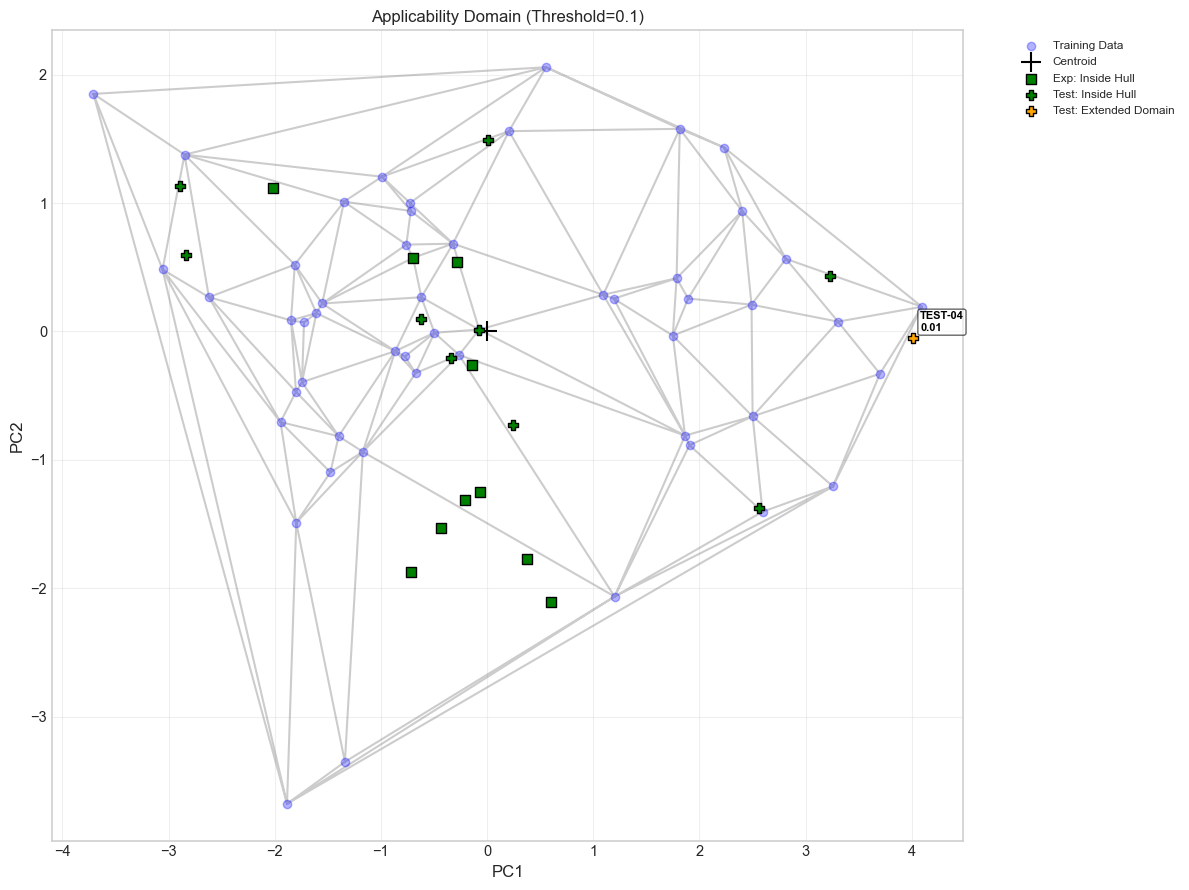


--- Detailed Report: Experimental Set ---
AD_Status
Inside Hull    10
Name: count, dtype: int64

[Extended Domain]: None

[Out of Domain]: None

--- Detailed Report: Test Set ---
AD_Status
Inside Hull        9
Extended Domain    1
Name: count, dtype: int64

[Extended Domain] Molecules (AD_ID | Original Index -> Rel_Distance):
  - TEST-04 | Index 52: 0.0134

[Out of Domain]: None


In [55]:
ad_results = analyze_applicability_heuristic(
    X_train=X_train,
    X_val=data[list(X_train.columns)],
    X_test=X_test,
    heuristic_threshold=0.10,
    output_dir=AD_OUTPUT_DIR,
)

X_val_ad = ad_results["exp_results_df"].copy()
X_test_ad = ad_results["test_results_df"].copy()

In [57]:
X_test

,IC1,GATS6are,ATSC1c,CIC1,GATS4d,PEOE_VSA6,SMR_VSA6
index,,,,,,,
11,2.215431,1.700711,-0.084079,3.428425,1.009779,103.137893,0.000000
13,2.138687,1.302255,-0.081634,3.446276,1.042077,109.223566,0.000000
41,2.719416,1.389052,-0.201783,2.638136,0.824339,66.739691,0.000000
52,3.392153,1.191591,-0.545758,2.415202,1.005541,52.337799,19.972449
59,2.926247,0.176270,-0.069788,1.881108,0.631169,36.407855,0.000000
31,2.579349,1.702707,-0.089432,2.778203,0.975070,66.730038,0.000000
18,2.602357,0.800758,-0.274570,2.952232,0.847059,78.872425,0.000000
27,2.653997,1.188641,-0.089328,2.869565,0.875264,66.739691,0.000000
29,2.634762,0.933649,-0.172214,2.950201,1.121591,78.862772,7.109798


#test_data_points
11	SCc1ccccc1.C(=C/c1ccc2ccccc2c1)\C(=O)c1ccccc1	94	test
13	SCc1ccccc1.C(=C/C=C/c1ccccc1)\C(=O)c1ccccc1	96
41	Sc1occc1C.C(=C/c1ccccc1)\C(=O)c1ccccc1	40
52	SCC1(CC(=O)OC)CC1.C(=C/c1cccc(Br)c1)\C(=O)c1ccccc1C(=O)OC	44
59	SCc1ccccc1.C1=CCCC1=O	80
31	SCc1ccccc1.C(=Cc1cccs1)C(=O)c1ccccc1	85
18	SCc1ccc(C(F)(F)F)cc1.C(=C/c1ccccc1)\C(=O)c1ccccc1	90
27	SCc1ccccc1.C(=C/c1ccc([N+](=O)[O-])cc1)\C(=O)c1ccccc1	25
29	SCc1ccccc1.C(=C/c1ccccc1OC)\C(=O)c1ccccc1	67
56	SCC(=O)OC.C(=C/c1ccccc1C(F)(F)F)\C(=O)c1ccccc1	1.5



In [58]:
test_df

,IC1,GATS6are,ATSC1c,CIC1,GATS4d,PEOE_VSA6,SMR_VSA6,ee
index,,,,,,,,
11,2.215431,1.700711,-0.084079,3.428425,1.009779,103.137893,0.000000,94.0
13,2.138687,1.302255,-0.081634,3.446276,1.042077,109.223566,0.000000,96.0
41,2.719416,1.389052,-0.201783,2.638136,0.824339,66.739691,0.000000,40.0
52,3.392153,1.191591,-0.545758,2.415202,1.005541,52.337799,19.972449,44.0
59,2.926247,0.176270,-0.069788,1.881108,0.631169,36.407855,0.000000,80.0
31,2.579349,1.702707,-0.089432,2.778203,0.975070,66.730038,0.000000,85.0
18,2.602357,0.800758,-0.274570,2.952232,0.847059,78.872425,0.000000,90.0
27,2.653997,1.188641,-0.089328,2.869565,0.875264,66.739691,0.000000,25.0
29,2.634762,0.933649,-0.172214,2.950201,1.121591,78.862772,7.109798,67.0


In [59]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D


def draw_molgrid_with_results(
    df,
    smiles_col="SMILES_tiol",
    smiles_col_2="SMILES_chalkon",
    obs_col="ee",
    pred_col="predicted_ee",
    hull_col="AD_Status",
    ad_id_col="AD_ID",
    n_per_row=4,
    max_mols=100,
    img_size=(400, 400),
):
    combined_mols = []
    legends = []

    df_subset = df.head(max_mols)

    for idx, row in df_subset.iterrows():
        smi1 = str(row[smiles_col])
        smi2 = str(row[smiles_col_2])

        combined_smi = f"{smi1}.{smi2}"
        mol = Chem.MolFromSmiles(combined_smi)

        if mol is not None:
            combined_mols.append(mol)

            obs = float(row[obs_col])
            pred = float(row[pred_col])
            hull = str(row[hull_col])
            error = abs(obs - pred)

            # Uses e.g. TEST-03 / EXP-07.
            # If AD_ID is absent, falls back to original dataframe index.
            mol_id = (
                str(row[ad_id_col])
                if ad_id_col in df.columns
                else f"Index {idx}"
            )

            label = (
                f"{mol_id}\n"
                f"Obs: {obs:.1f} | Pred: {pred:.1f} | Err: {error:.1f}\n"
                f"AD: {hull}"
            )

            legends.append(label)

        else:
            print(f"SMILES conversion error on index {idx}")

    dopts = rdMolDraw2D.MolDrawOptions()
    dopts.legendFontSize = 24
    dopts.padding = 0.05
    dopts.bondLineWidth = 3

    img = Draw.MolsToGridImage(
        combined_mols,
        molsPerRow=n_per_row,
        subImgSize=img_size,
        legends=legends,
        useSVG=True,
        drawOptions=dopts,
    )

    return img

In [61]:
ad_molgrid_svg = draw_molgrid_with_results(
    df=ad_structures,
    smiles_col="SMILES_tiol",
    smiles_col_2="SMILES_chalkon",
    obs_col="observed_ee",
    pred_col="predicted_ee",
    hull_col="AD_Status",
    ad_id_col="AD_ID",
    n_per_row=3,
    max_mols=len(ad_structures),
    img_size=(400, 400),
)

display(ad_molgrid_svg)

NameError: name 'ad_structures' is not defined